In [36]:
import sys
import glob
import yaml
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt
import Utilities as Util
import numpy as np
plt.style.use("~/evanstyle.mplstyle")
sys.path.append("../")

import DataReduction 
import CryoAsicAnalysis


In [2]:
#change path!
#input_path = "/p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_Post_Surgery_7_15_24/"
input_path = "../../../data/MockTileRun1/Gamma_Data_Post_Surgery_7_15_24/prereduced/"
#change path!
#output_path = "/p/lustre2/nexouser/data/StanfordData/angelico/LXe_Run1_Processed_Data/Gamma_Data_Post_Surgery_7_15_24/Processed_Data/"
output_path = "../../../data/MockTileRun1/Gamma_Data_Post_Surgery_7_15_24/reduced/"
input_files = glob.glob(input_path+"*.p")
try:
	print(input_files[0])
except:
	print("No files found in input directory")
	print("Does directory exist?: ", os.path.isdir(input_path))

../../../data/MockTileRun1/Gamma_Data_Post_Surgery_7_15_24/prereduced/Gamma_Data_Post_Surgery_5kV_7_15_24_initcryo_4_6g_24pt_1000us_file15.p


In [3]:
config_path = "../config/gamma-post-surg-24.yml"
#either pass this directly to the class, or load it and modify with gain/pt settings corrected. 

#with open(config_path, 'r') as f:
#    config = yaml.safe_load(f)

#config["gain"] = 6 


In [87]:
#initialize the DataReduction class
dr = DataReduction.DataReduction(config_path)

Reducing file ../../../data/MockTileRun1/Gamma_Data_Post_Surgery_7_15_24/prereduced/Gamma_Data_Post_Surgery_5kV_7_15_24_initcryo_4_6g_24pt_1000us_file15.p
loading file ../../../data/MockTileRun1/Gamma_Data_Post_Surgery_7_15_24/prereduced/Gamma_Data_Post_Surgery_5kV_7_15_24_initcryo_4_6g_24pt_1000us_file15.p
Done
Subtracting baselines
Getting full STDs
Analyzing minimums and maximums
Initializing pulses for events with any sample above positive threshold of 6 sigma
Got 49 events with pulses


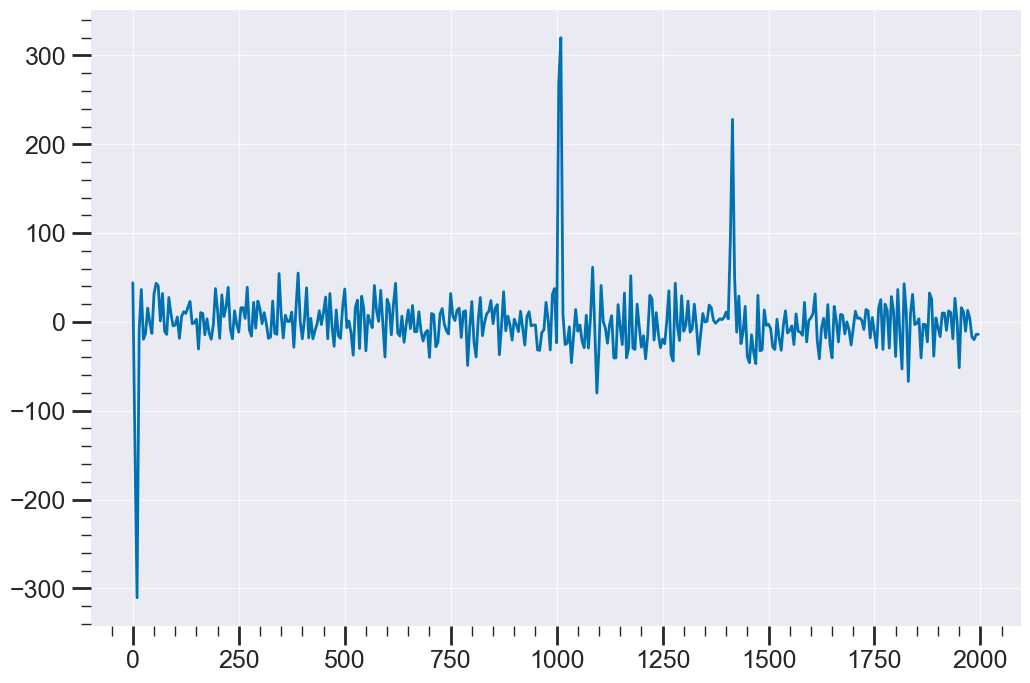

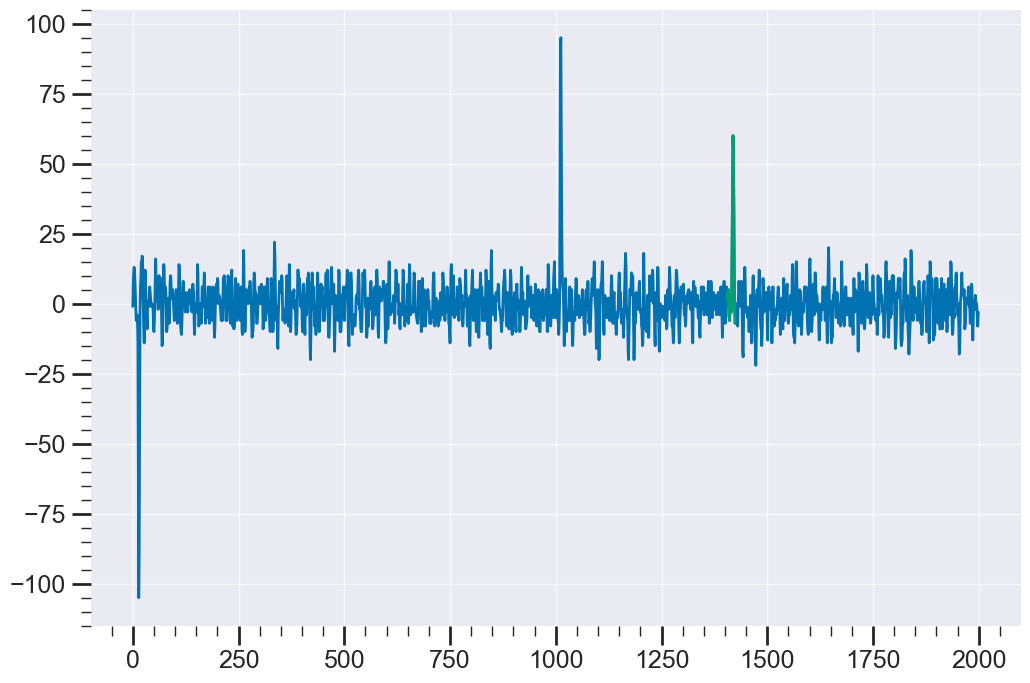

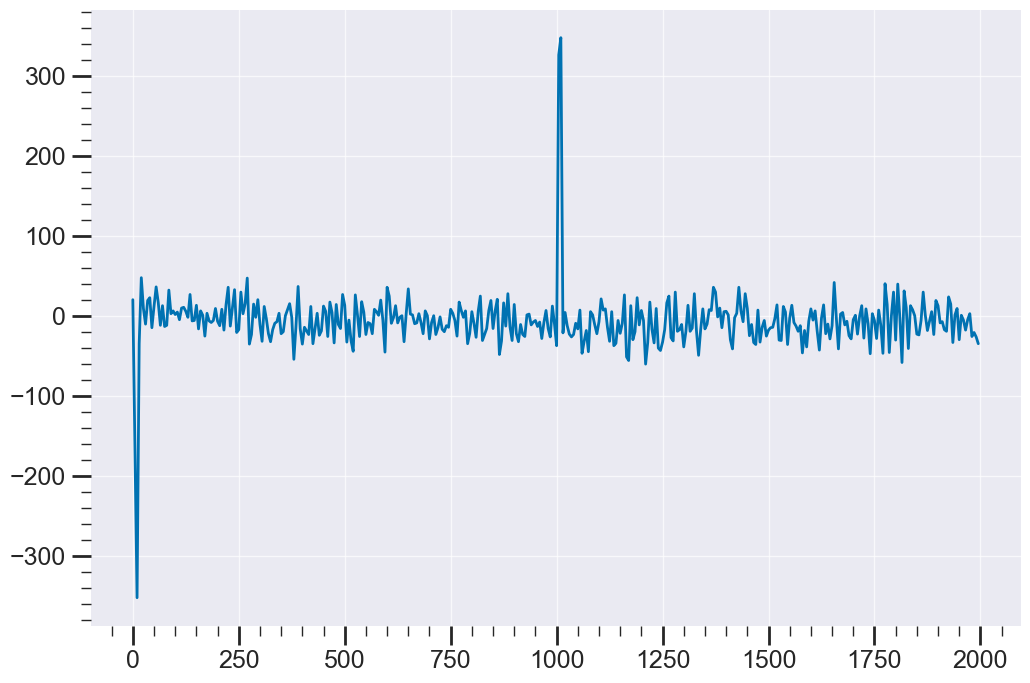

KeyboardInterrupt: 

In [103]:
#load input data of many files, which combines the dataframes into one
for infile in input_files:
	print("Reducing file {}".format(infile))
	dr.load_prereduced_data(infile)
	dr.reduce_to_pulses() #does basic initial waveform processing and creates Pulse objects
	dr.process_pulses() #analyzes the pulses in detail to populate pulse reduced quantities
	#dr.save_reduced_df(output_path, "reduced_6g_24pt.p")
	break

Got 49 events with pulses


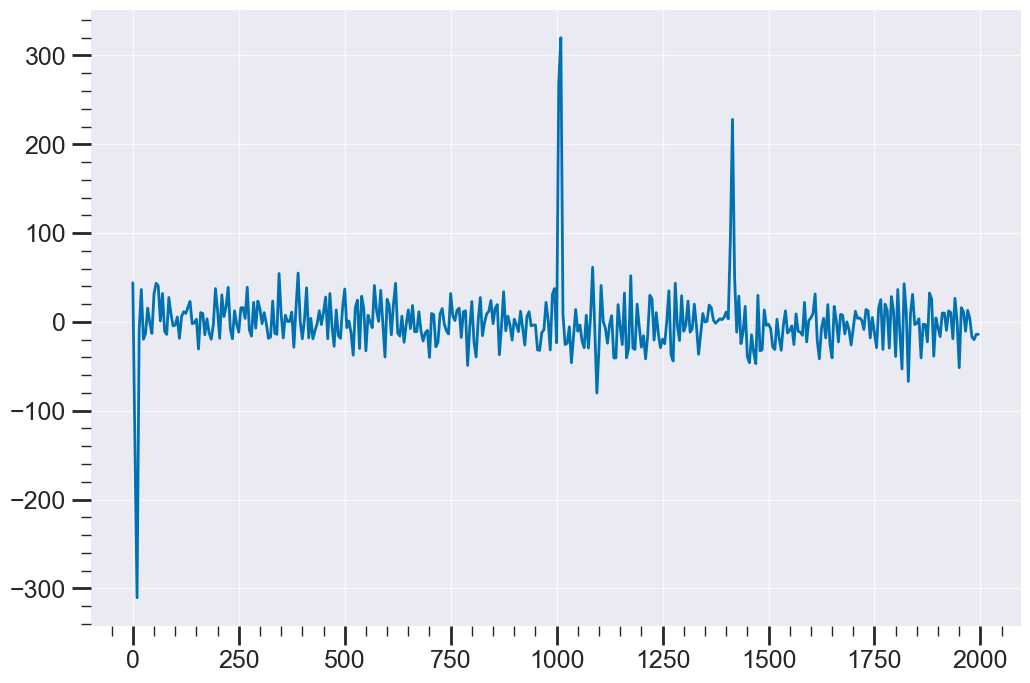

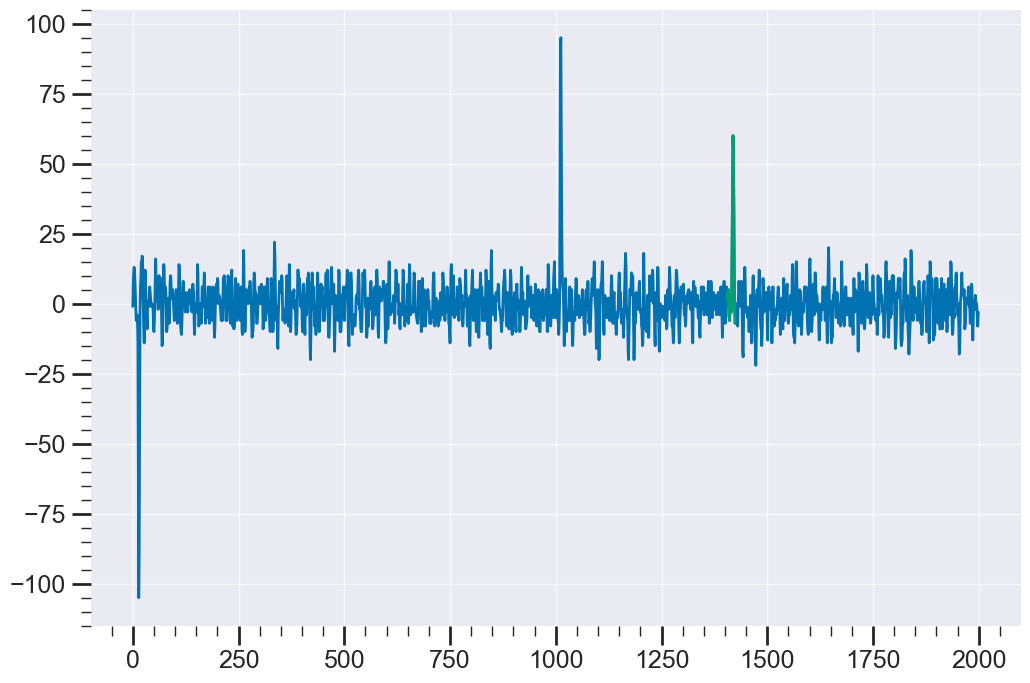

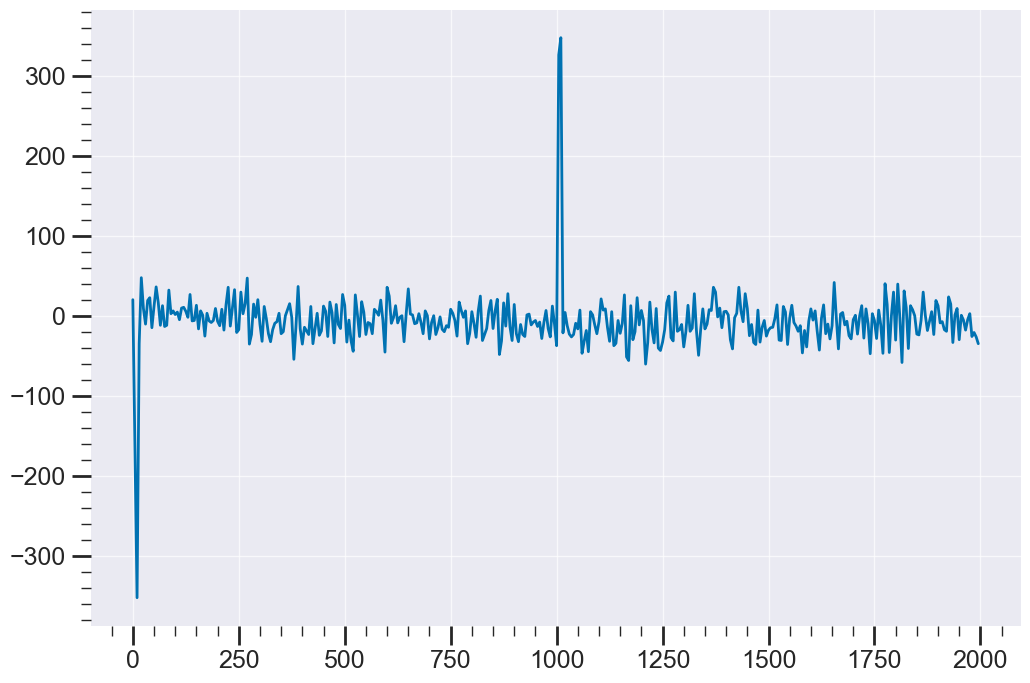

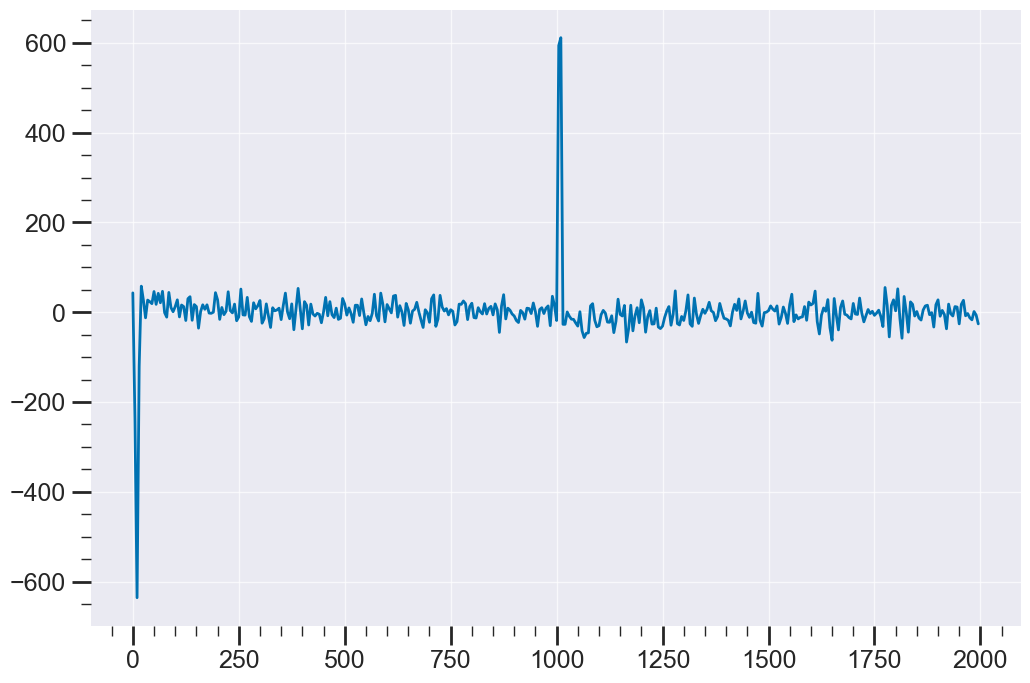

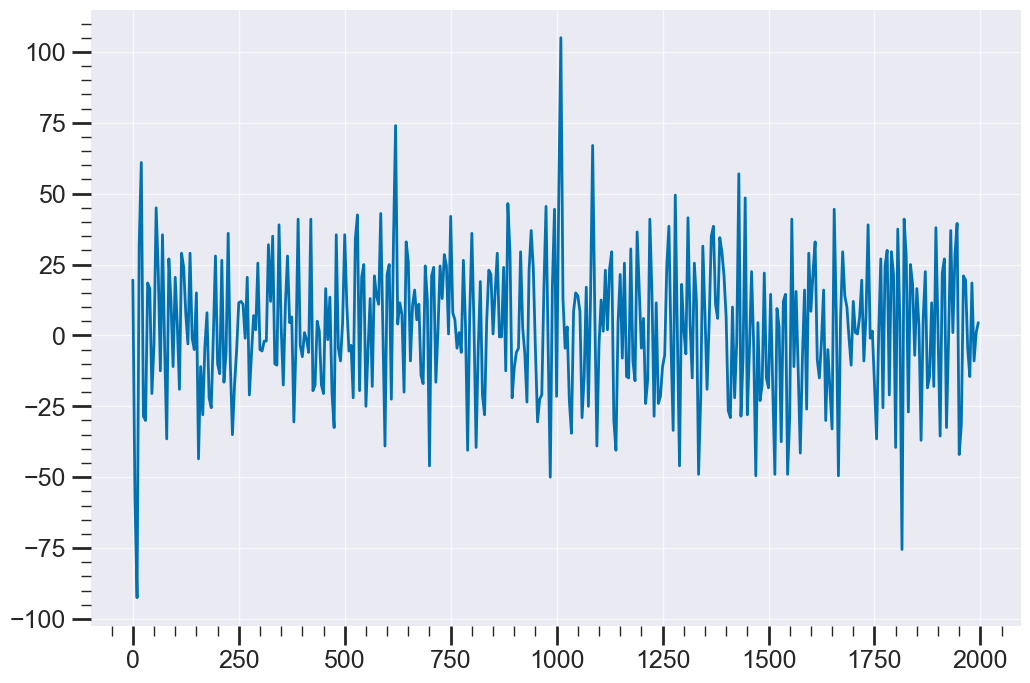

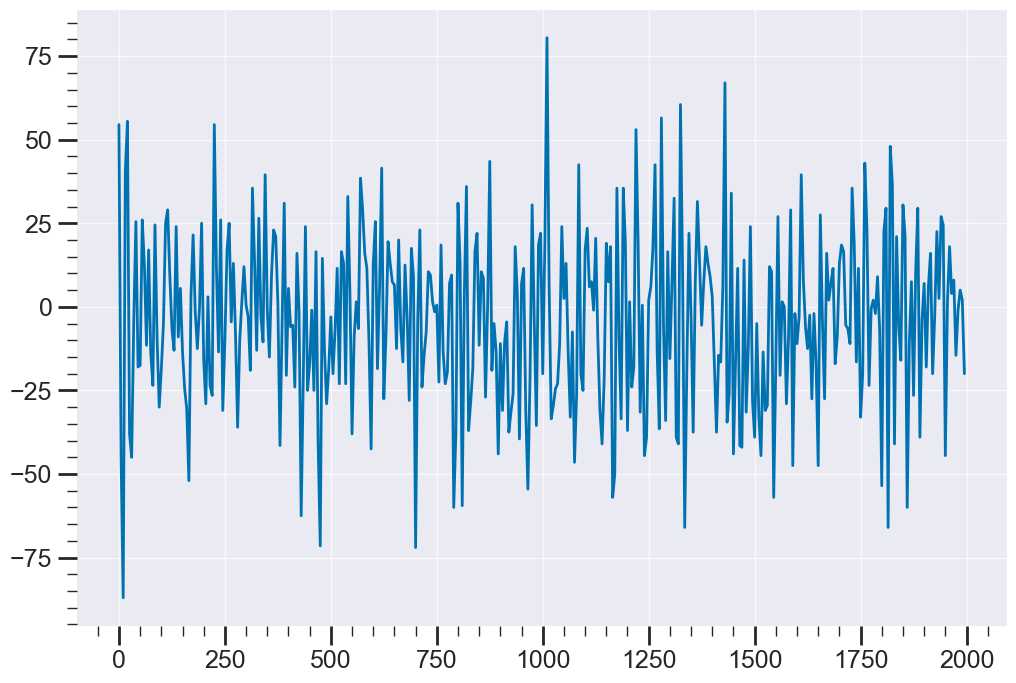

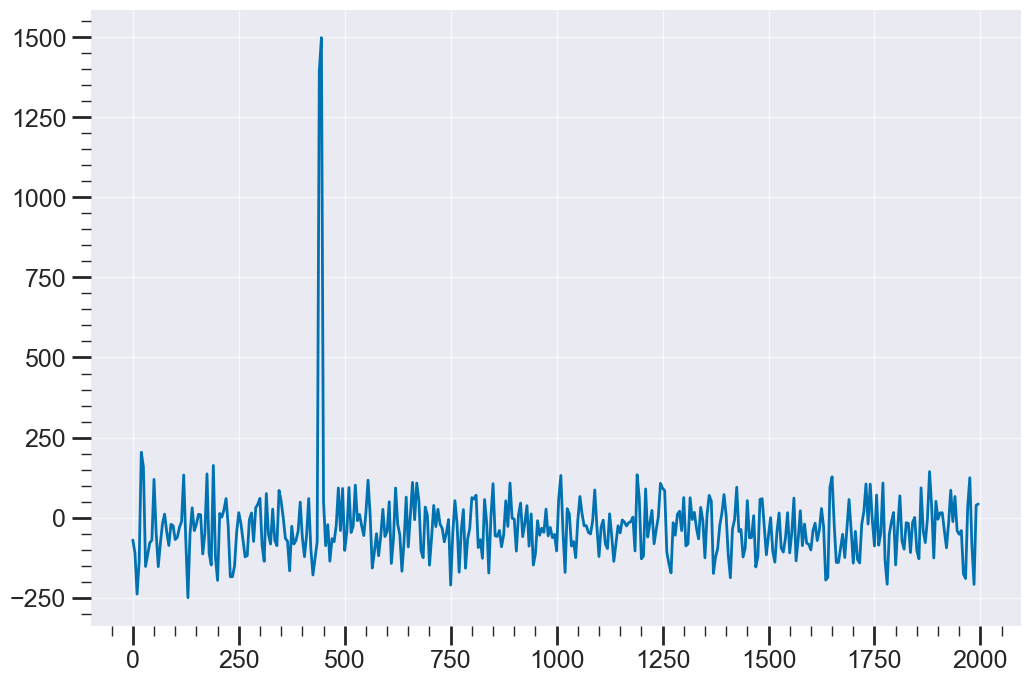

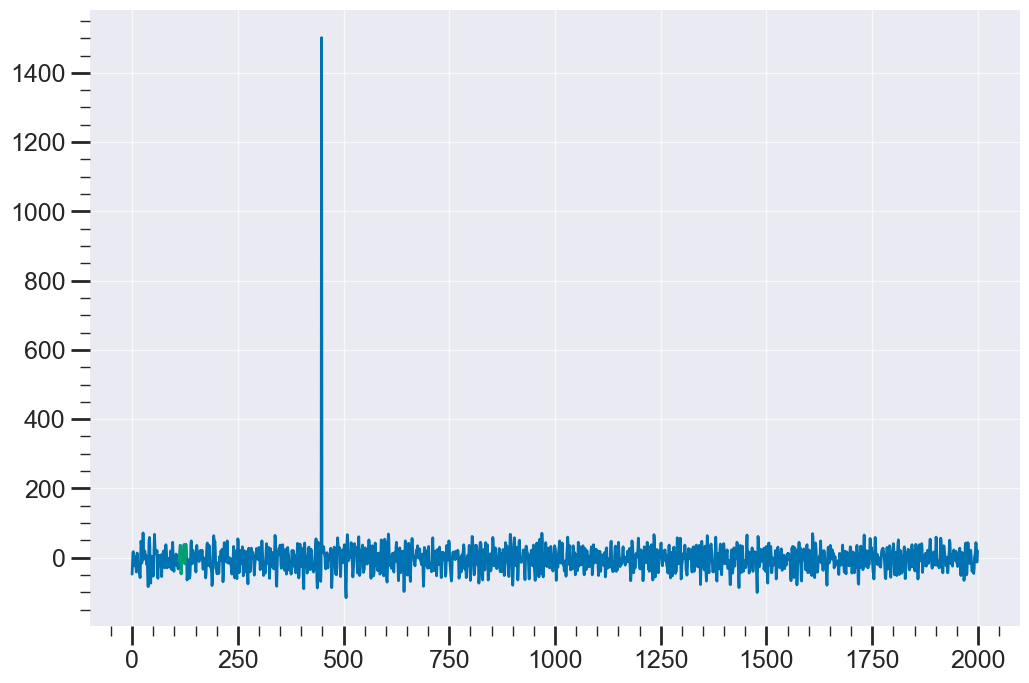

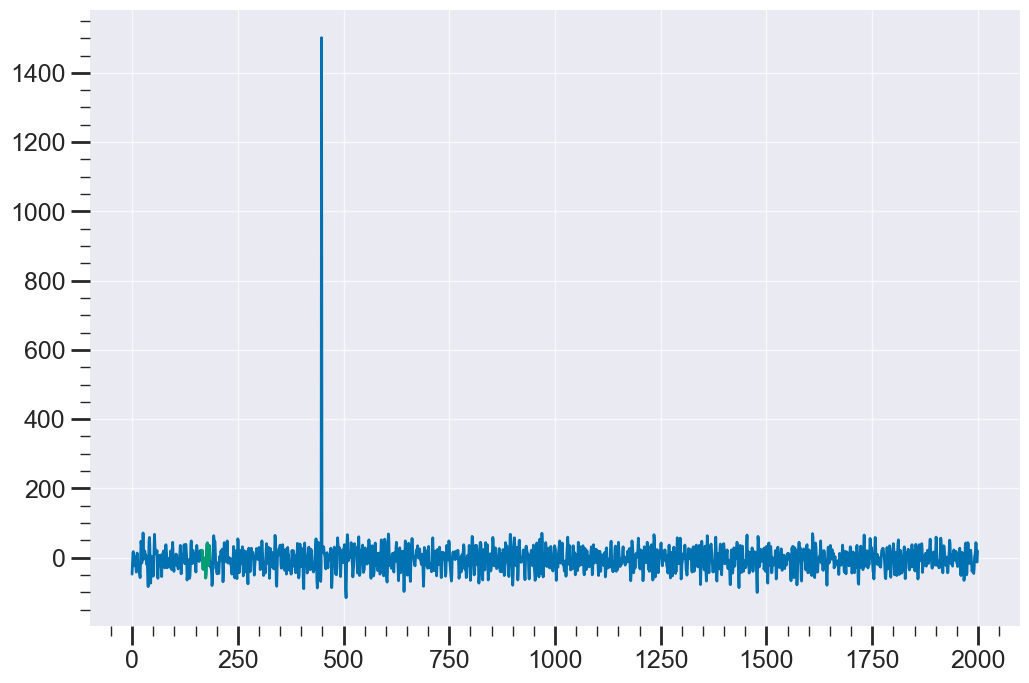

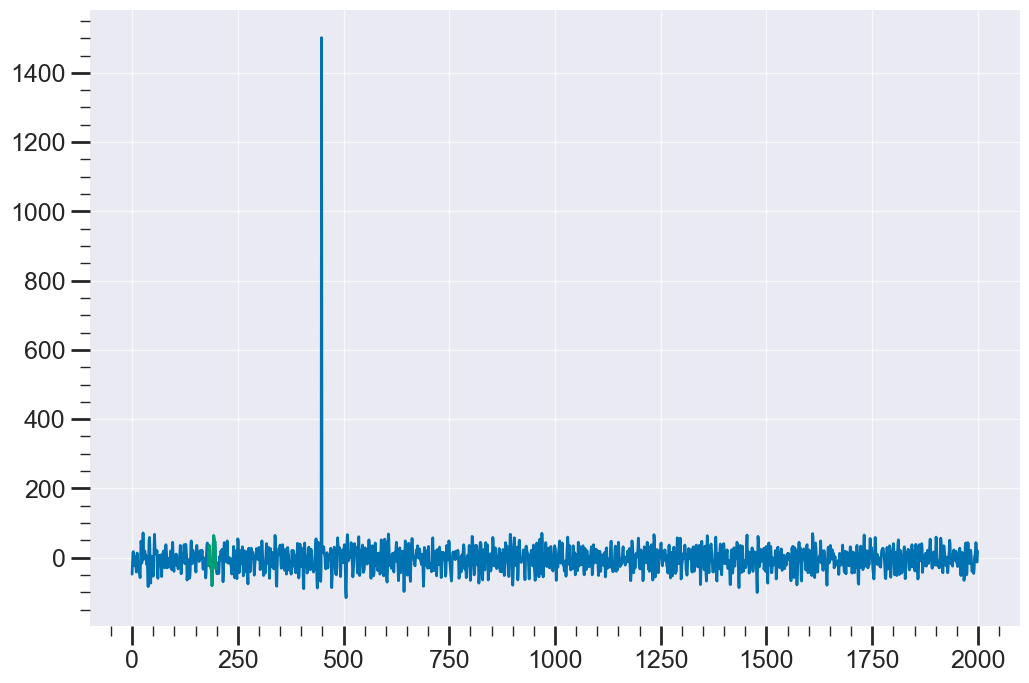

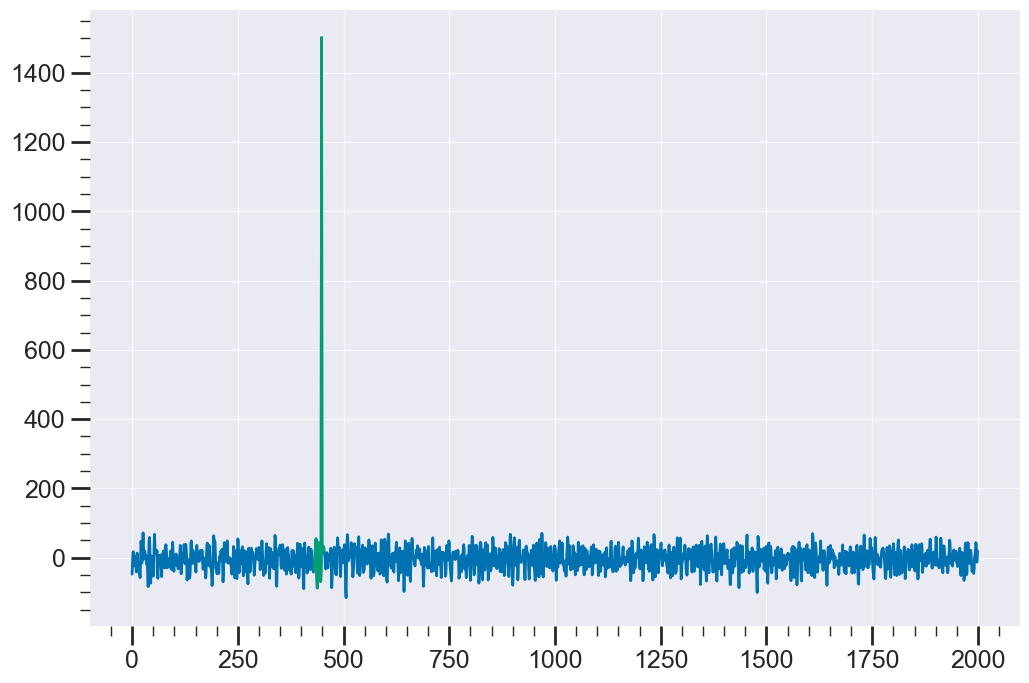

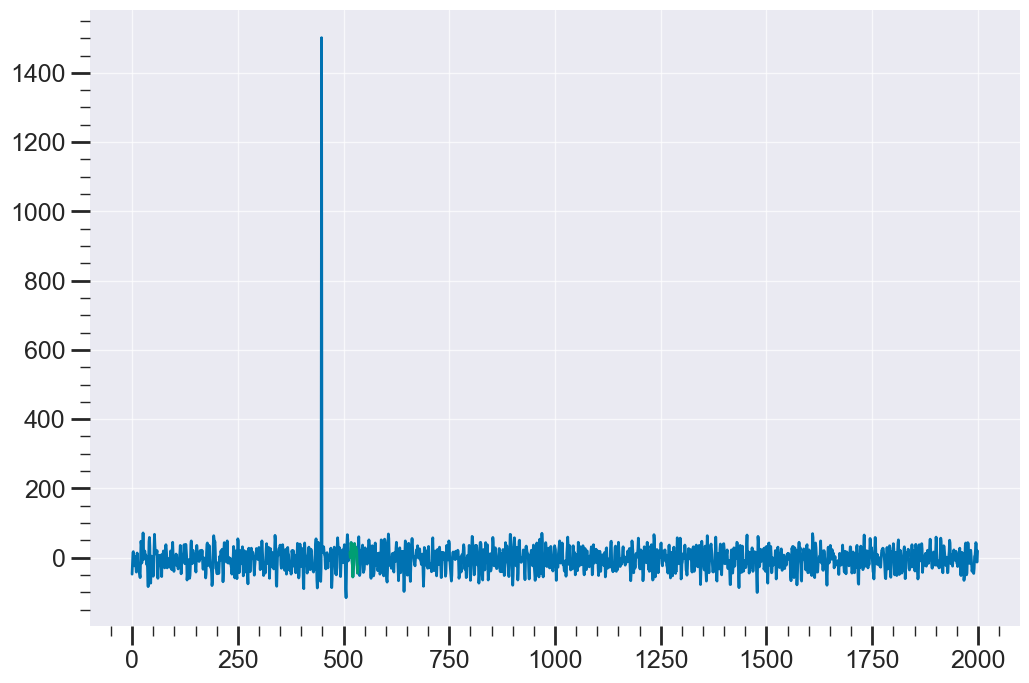

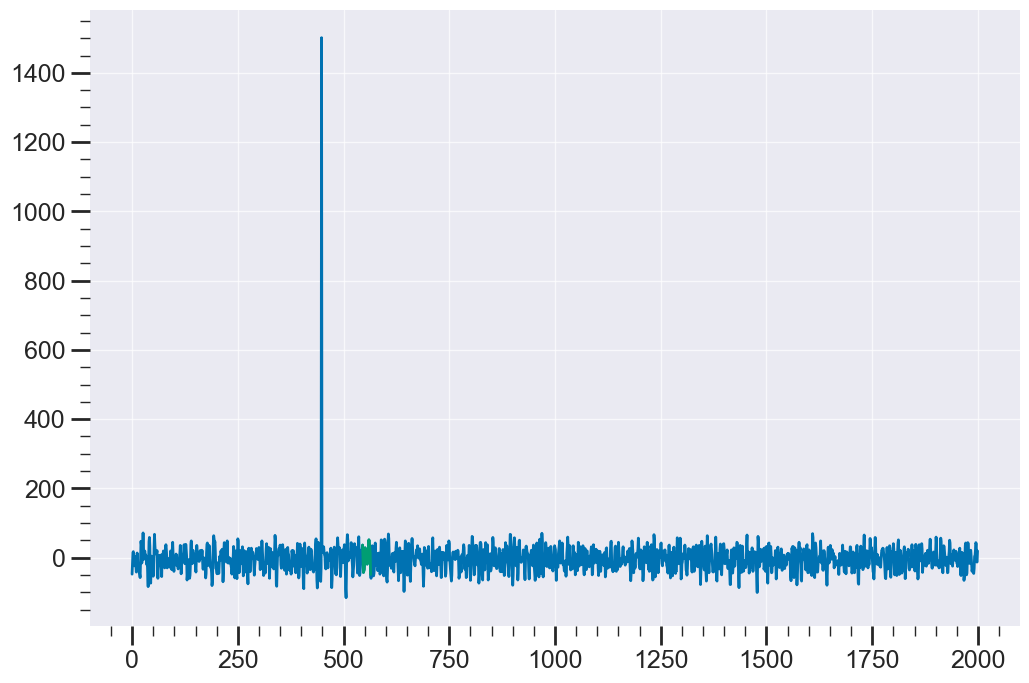

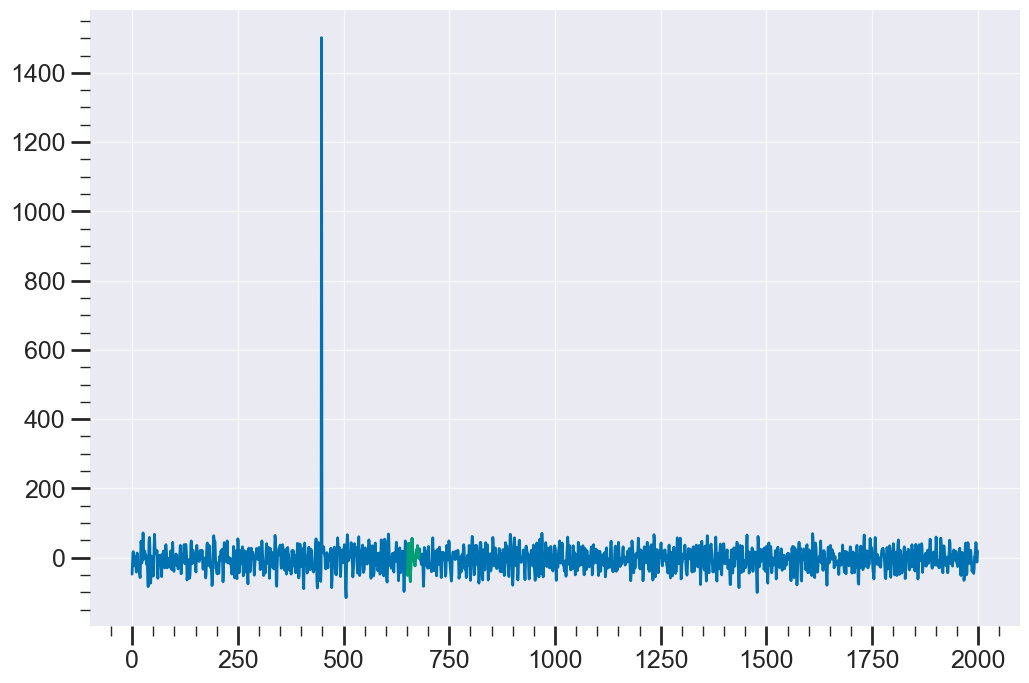

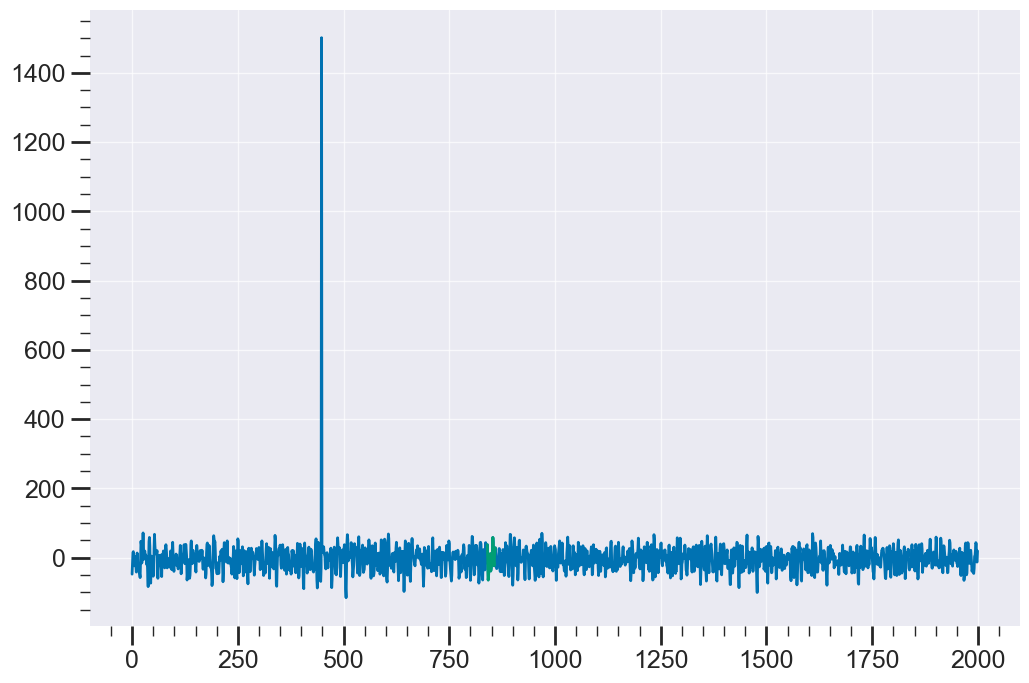

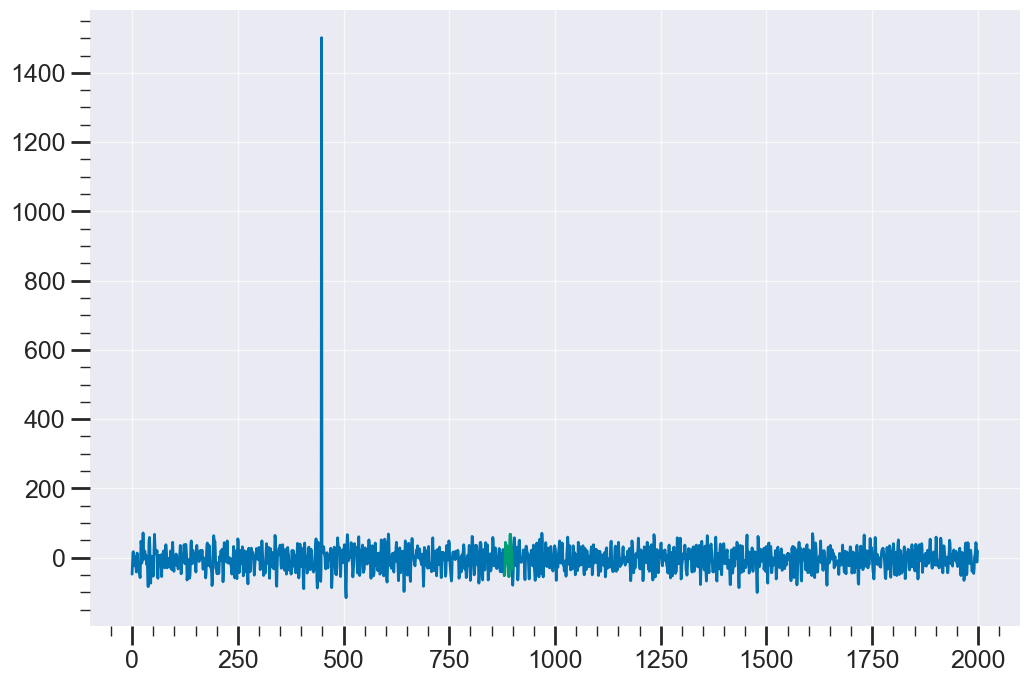

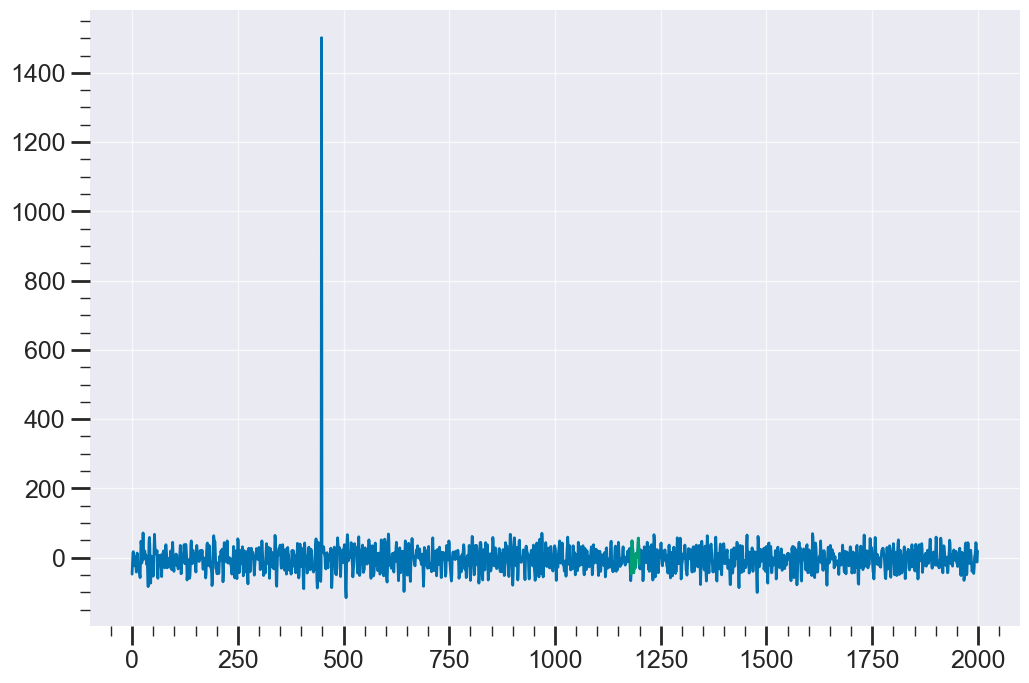

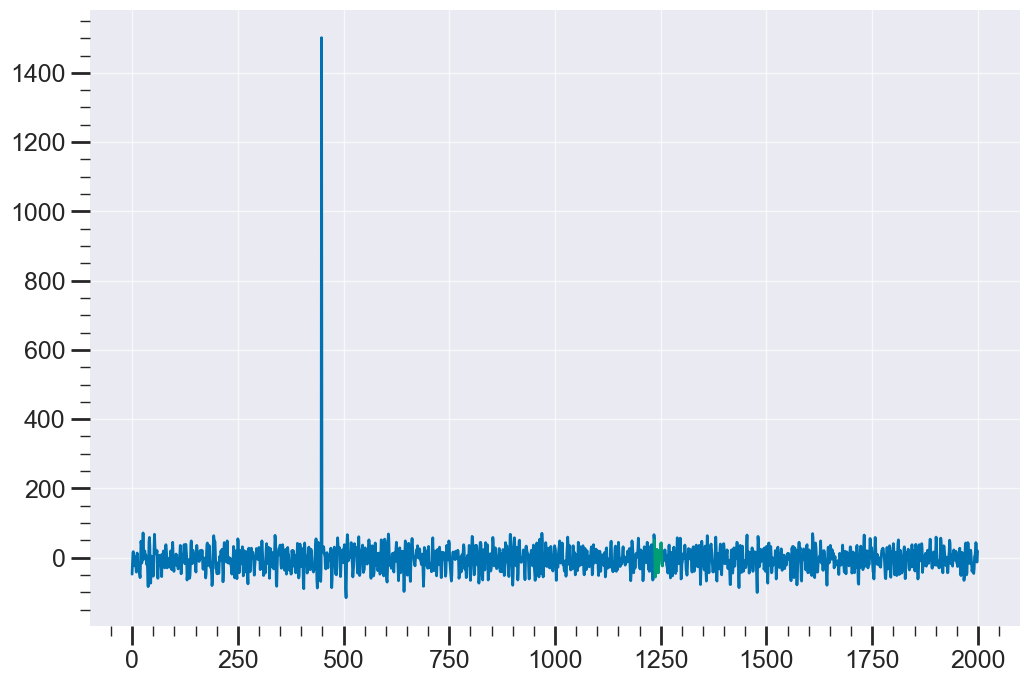

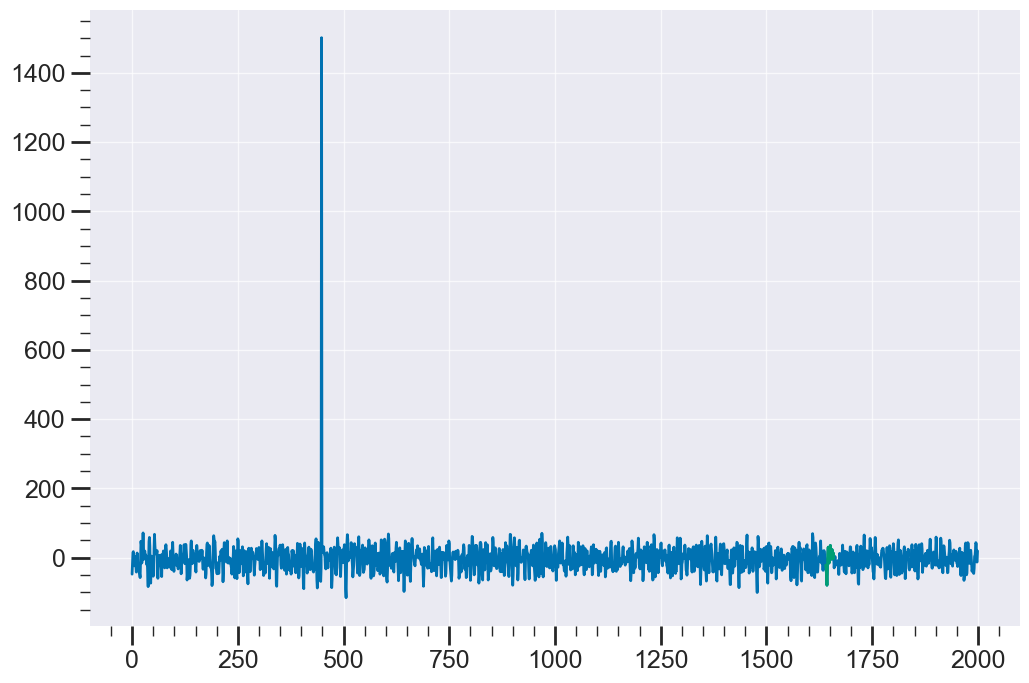

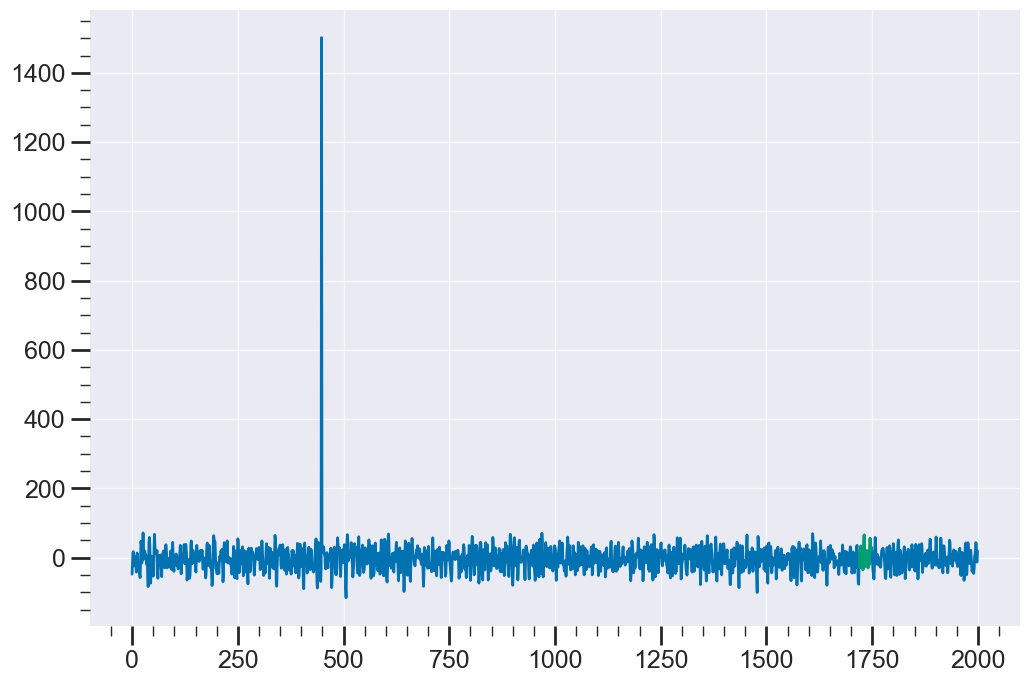

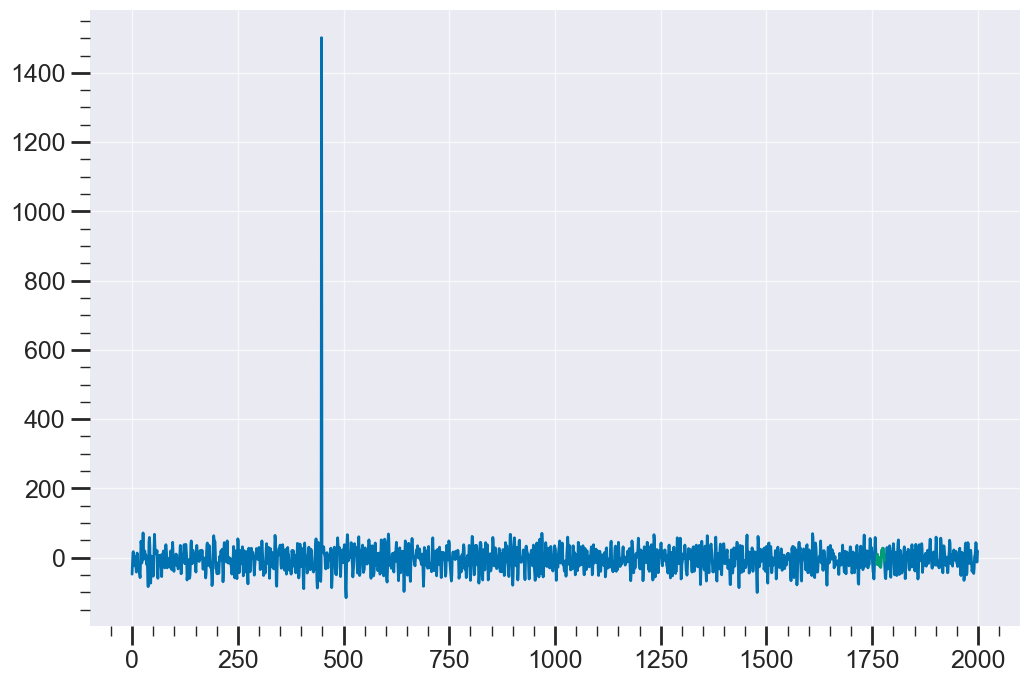

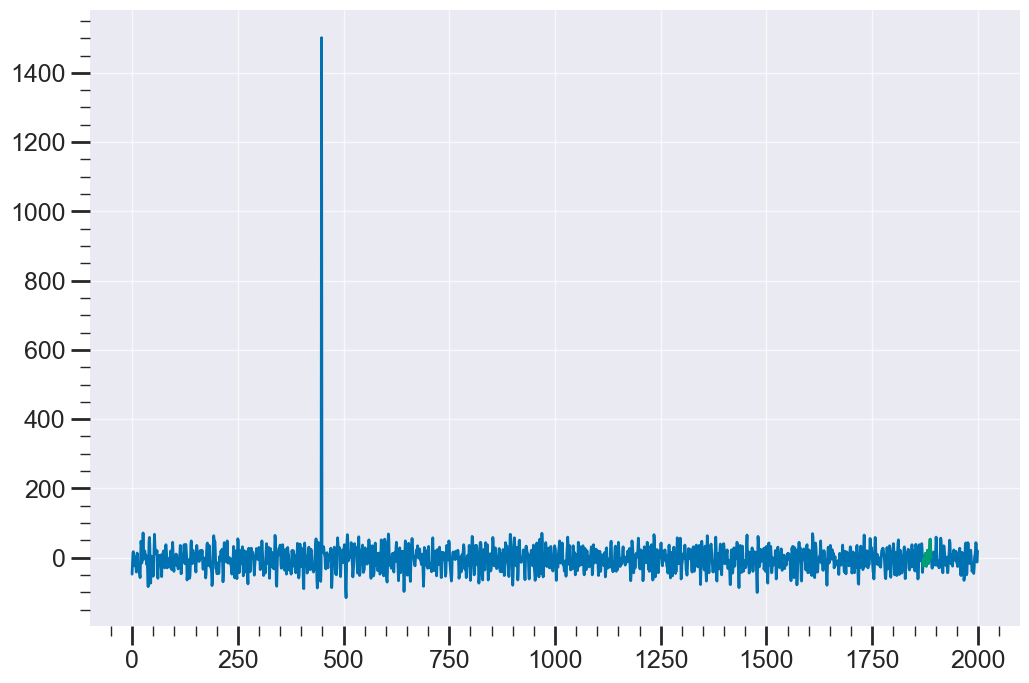

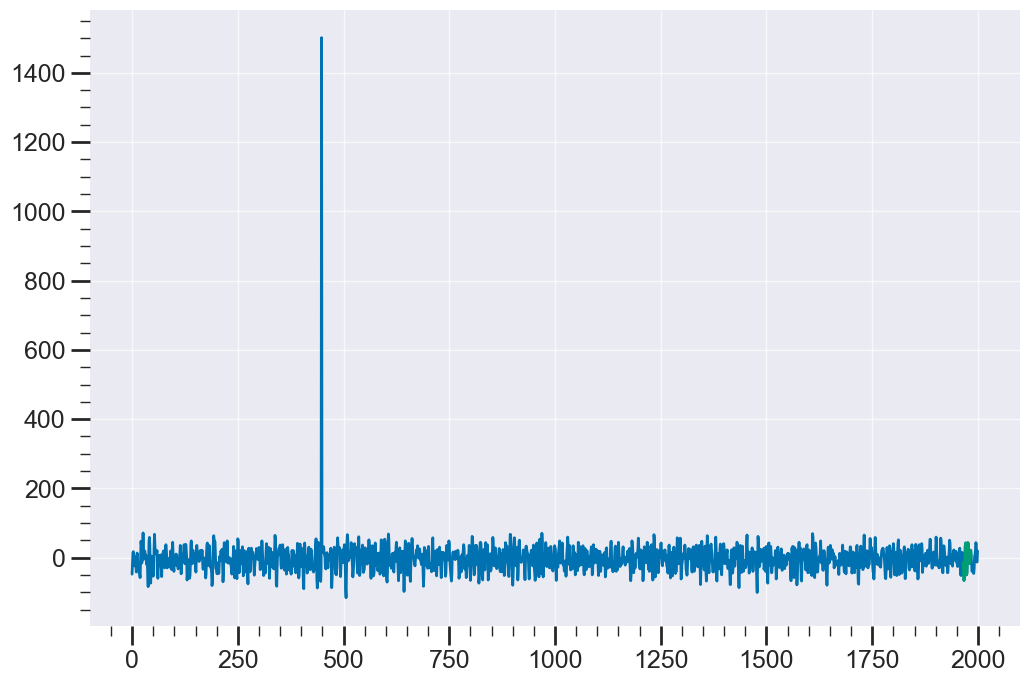

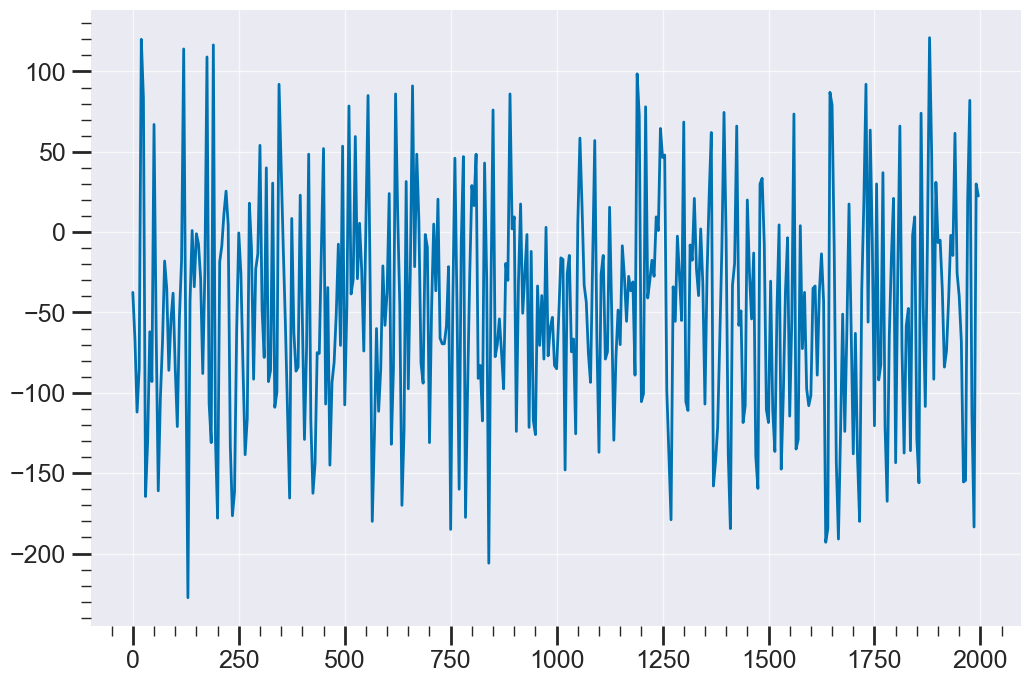

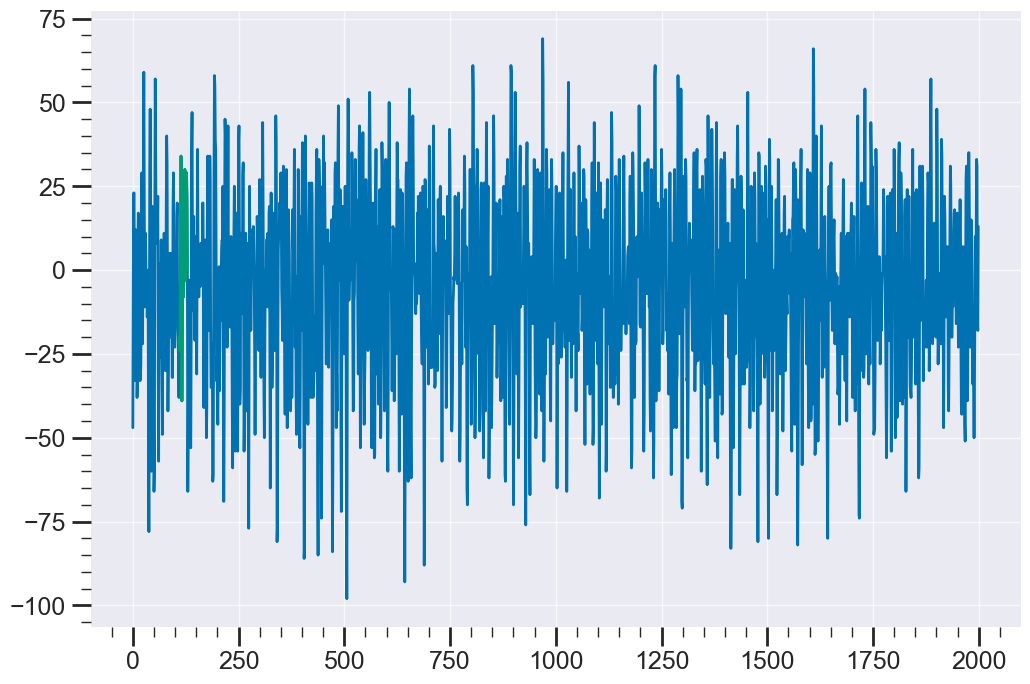

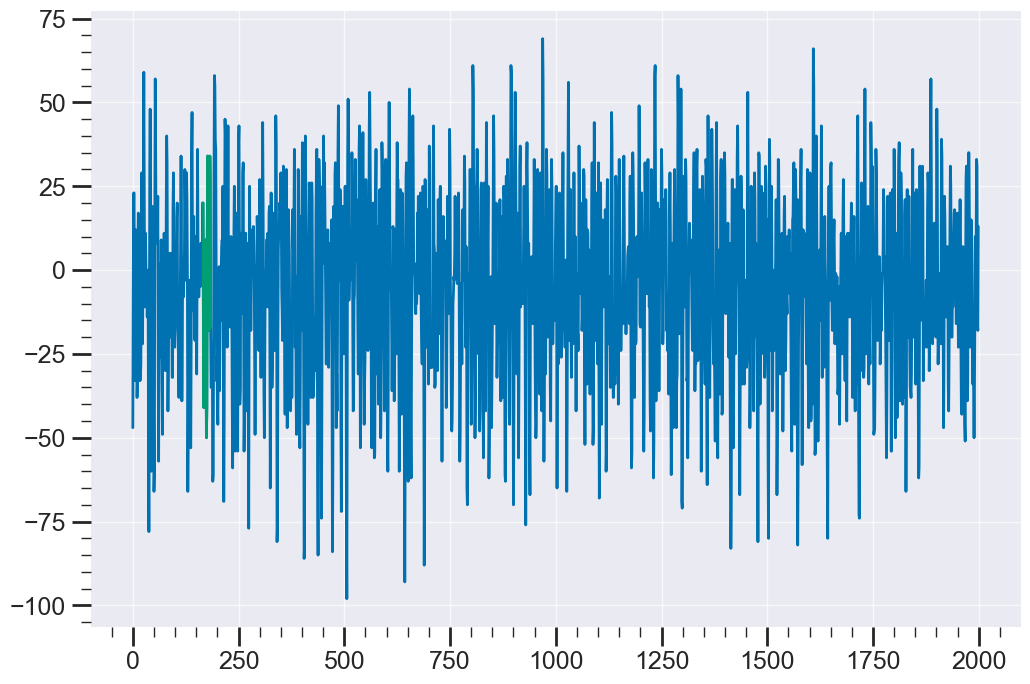

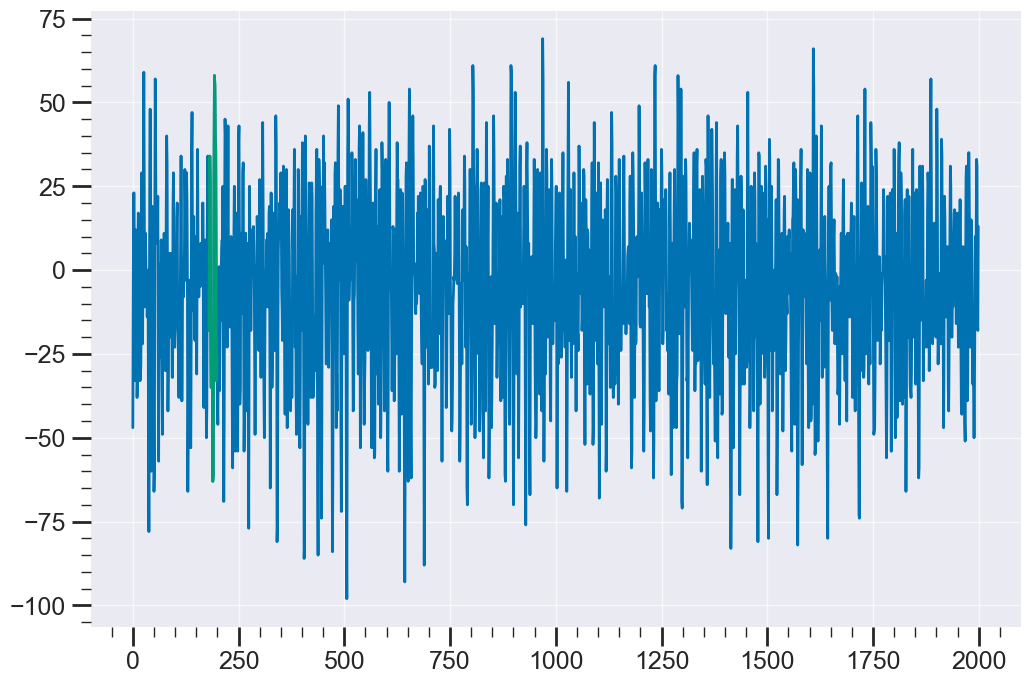

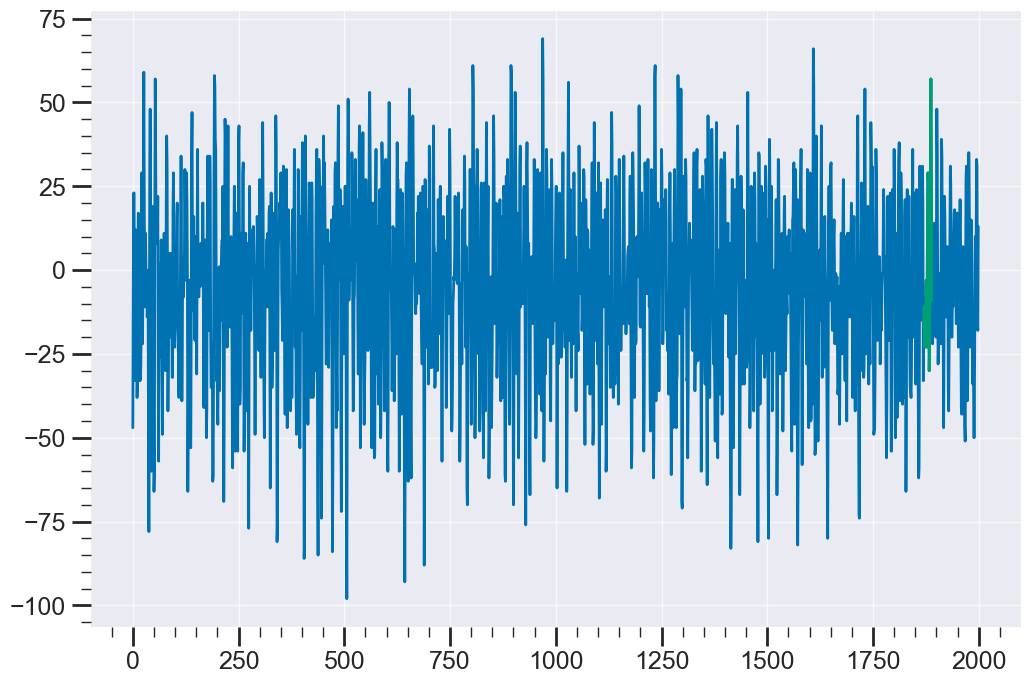

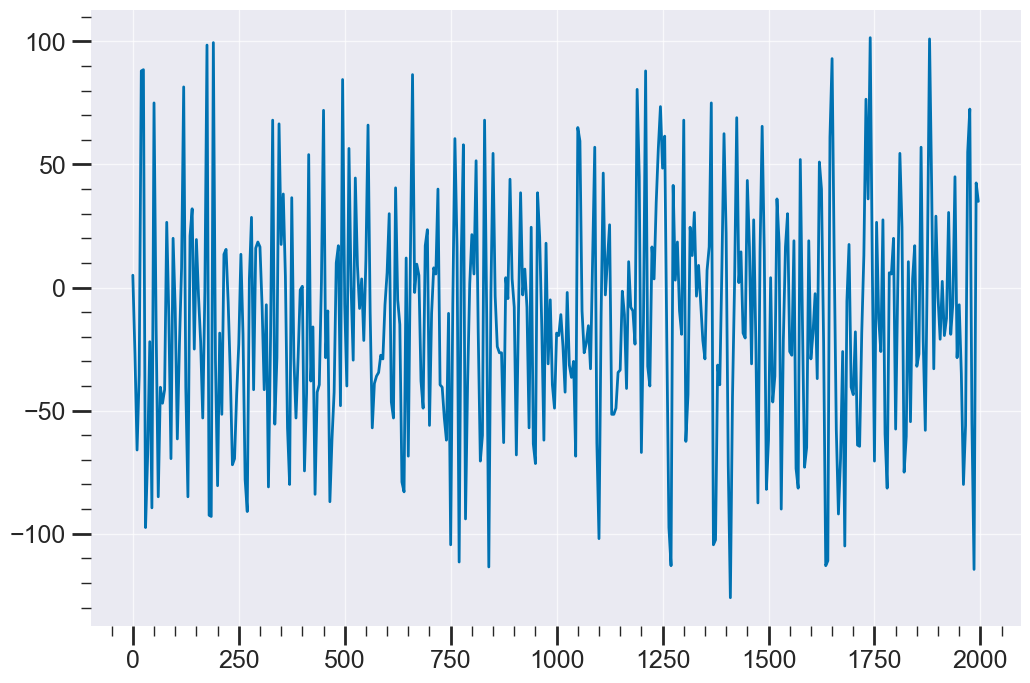

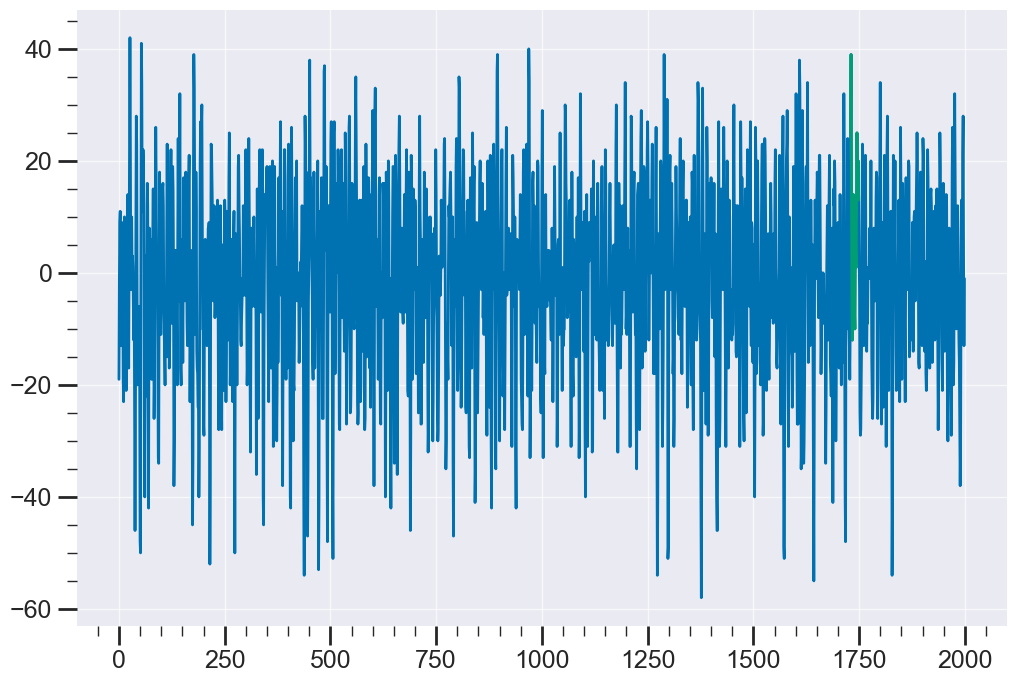

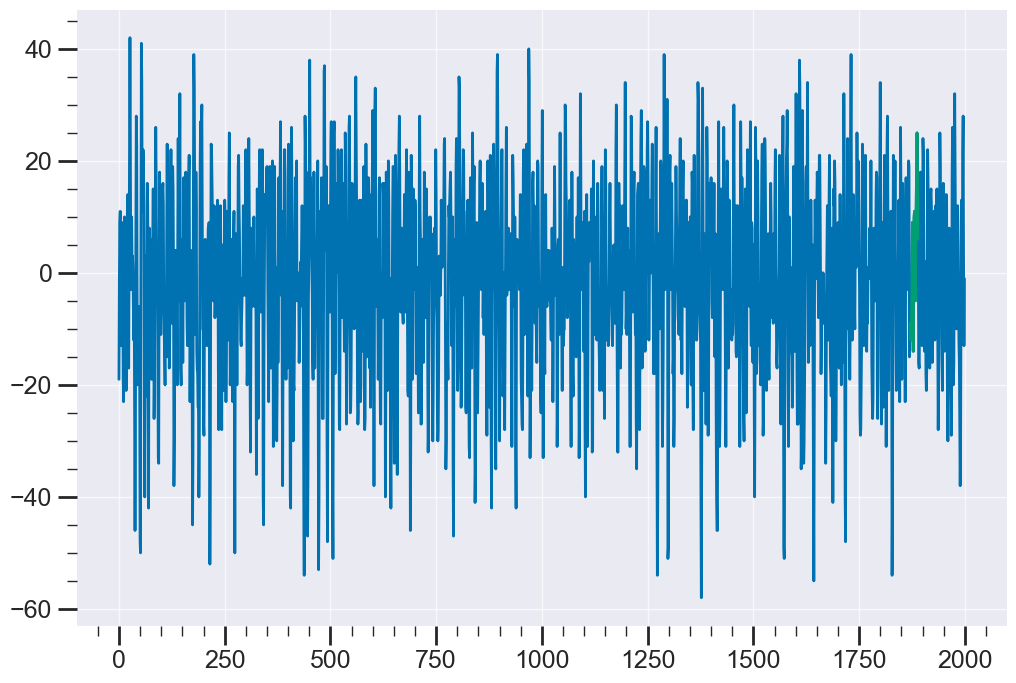

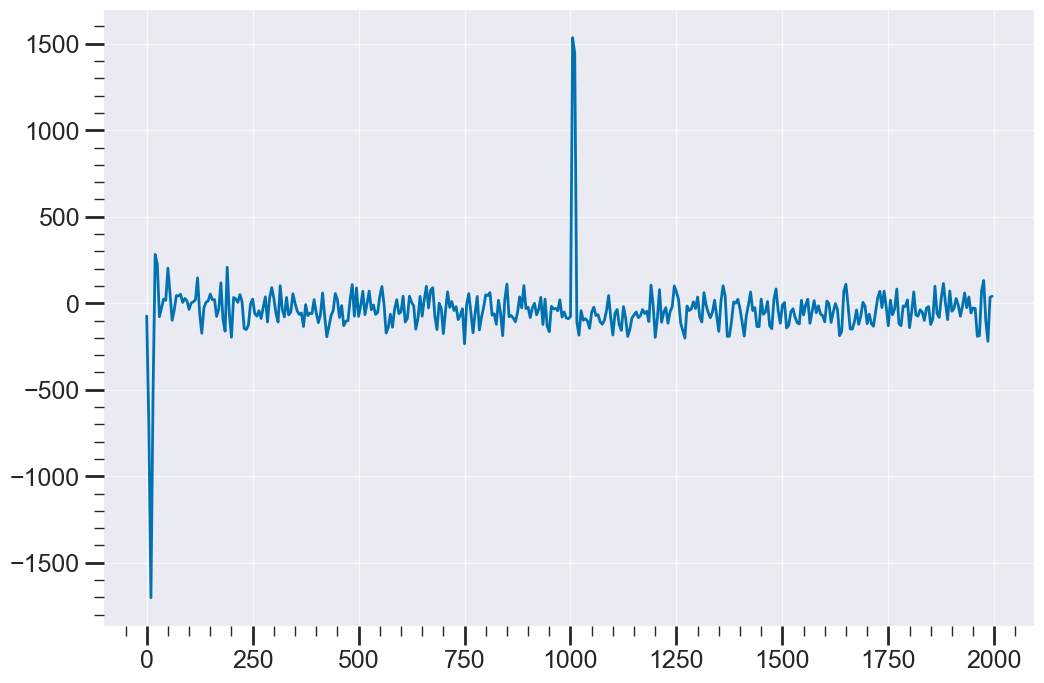

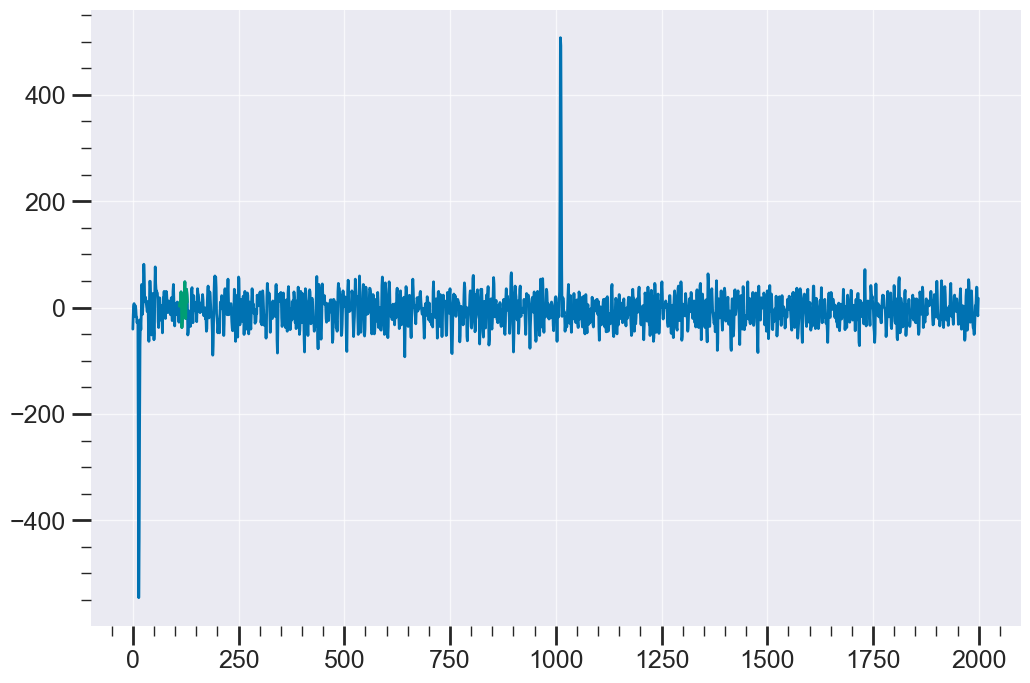

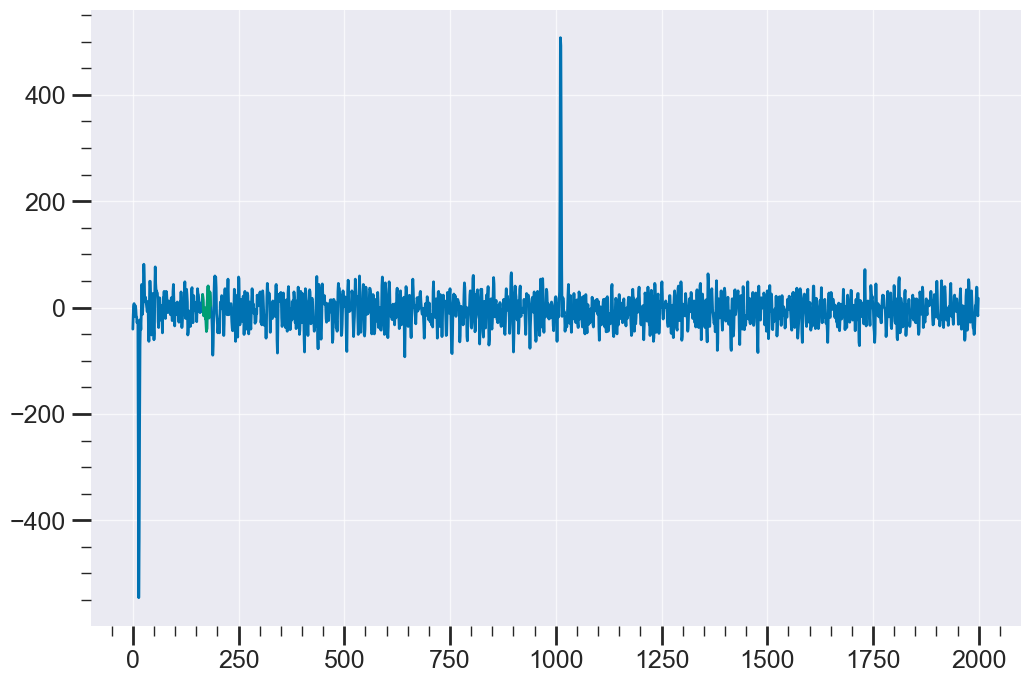

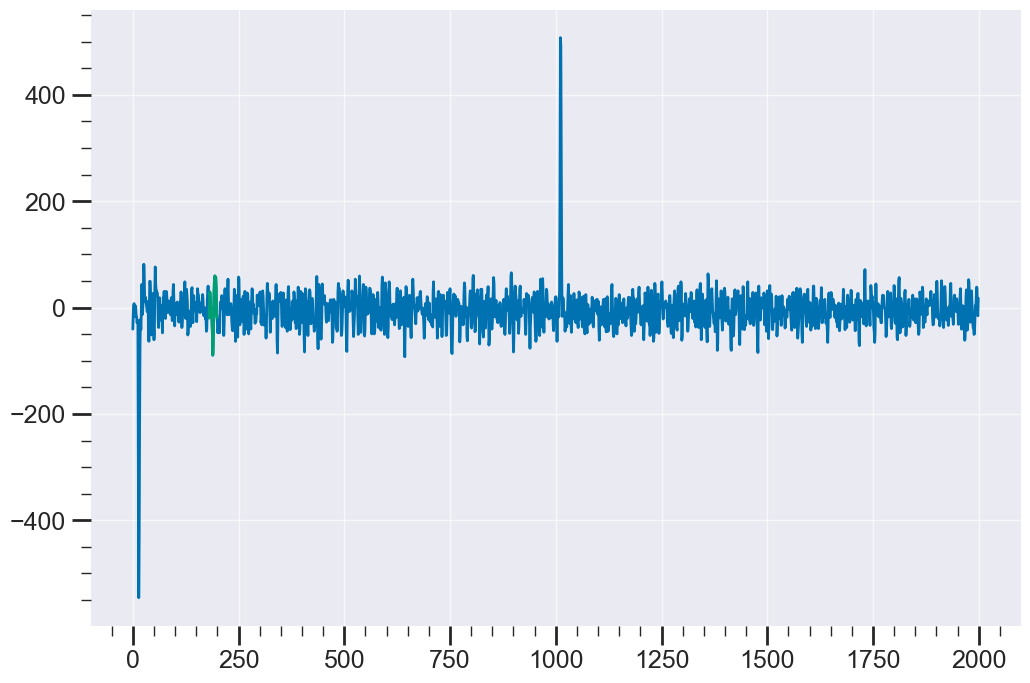

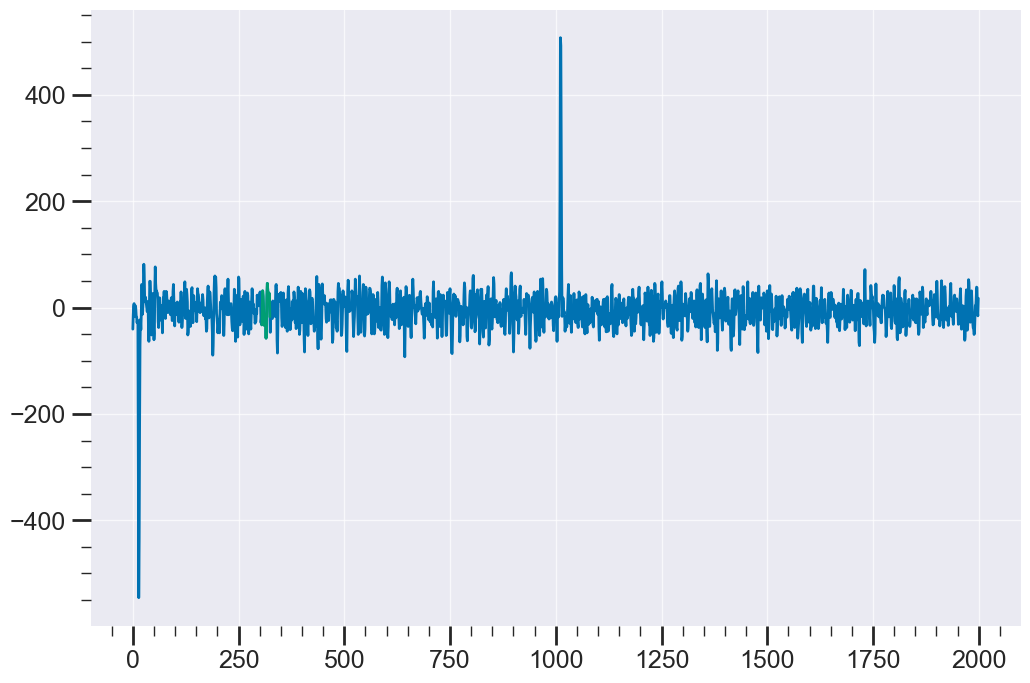

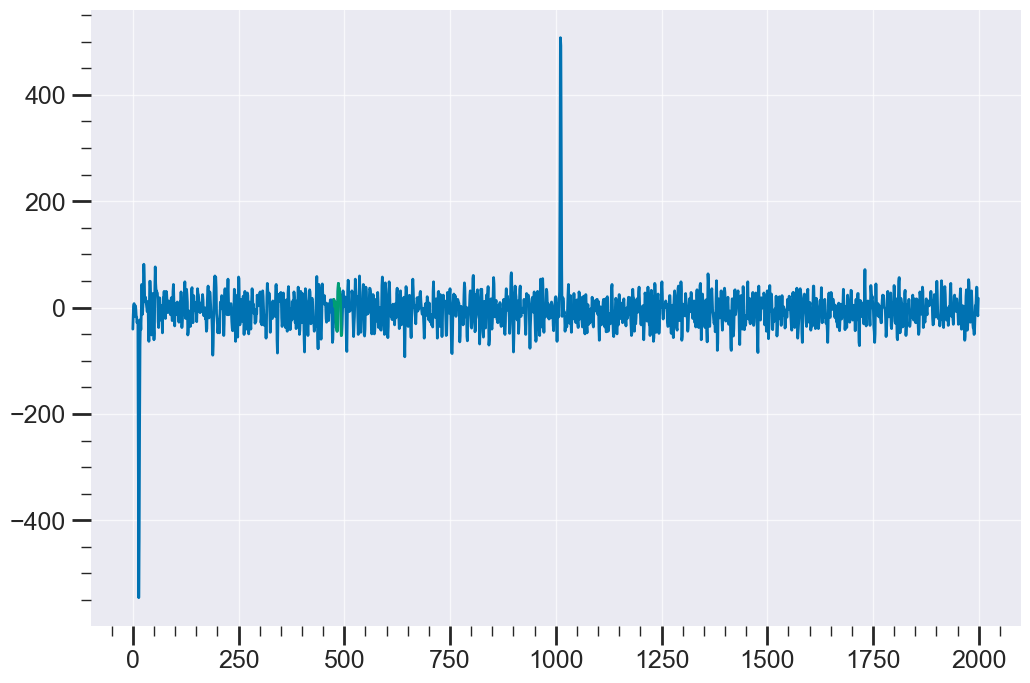

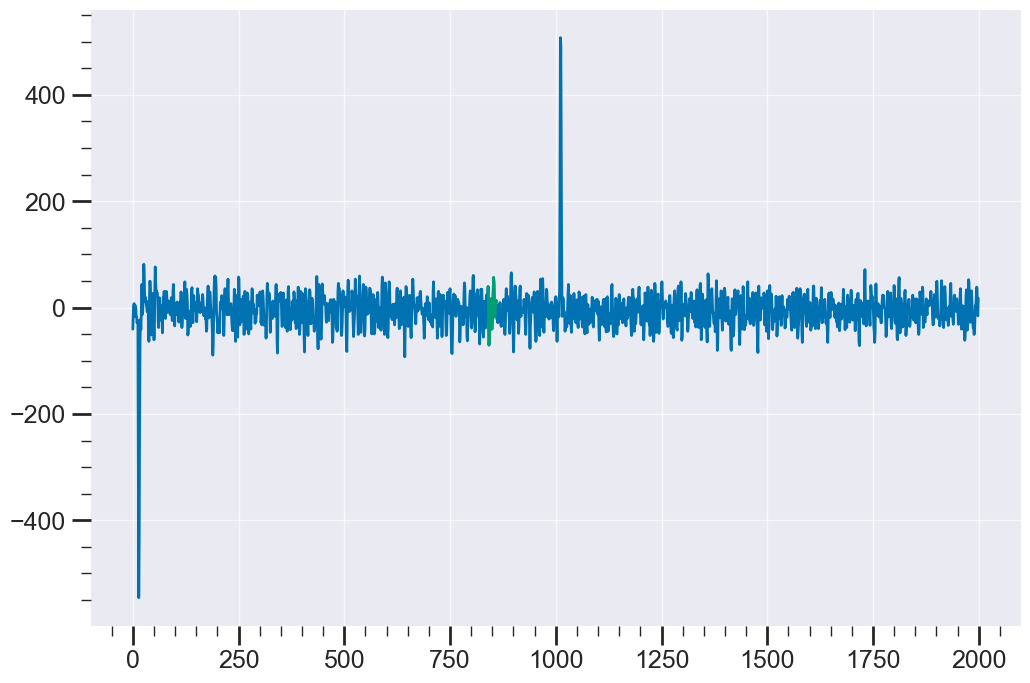

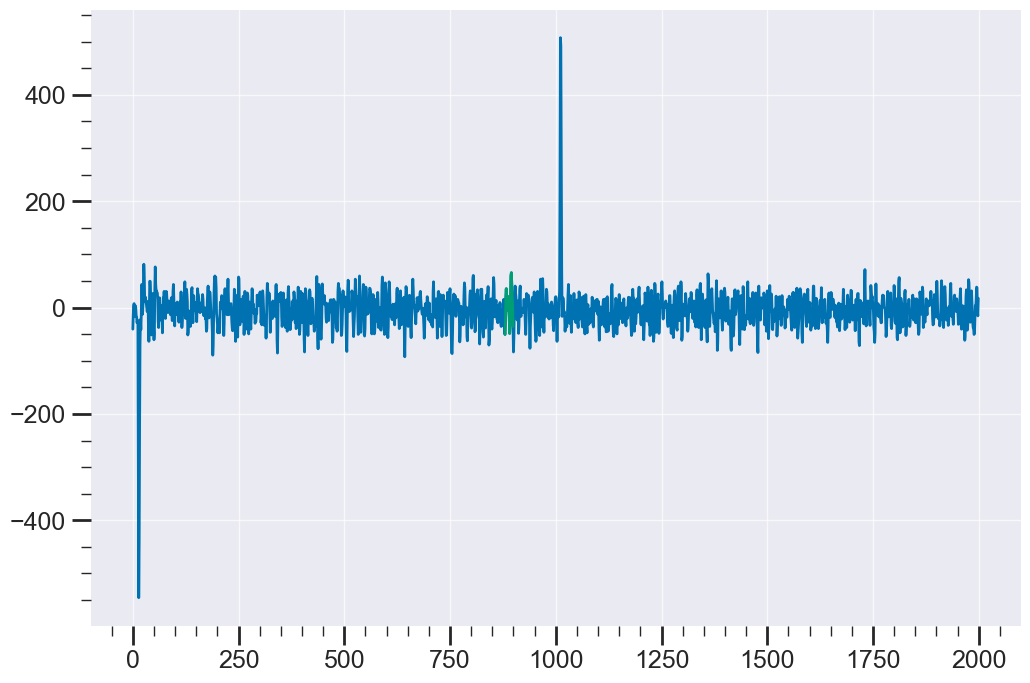

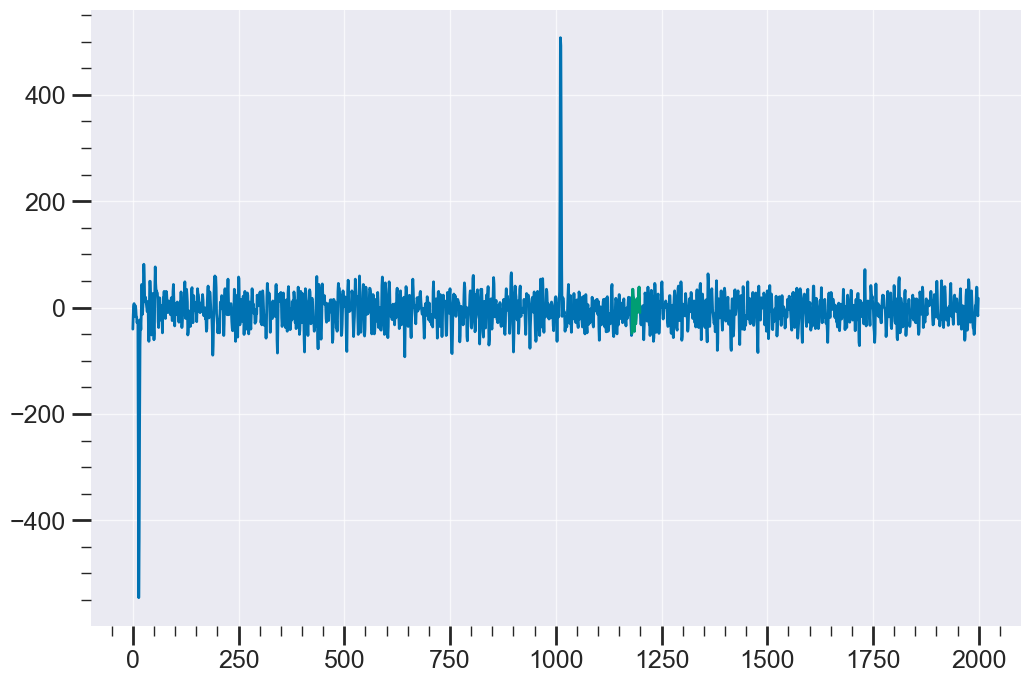

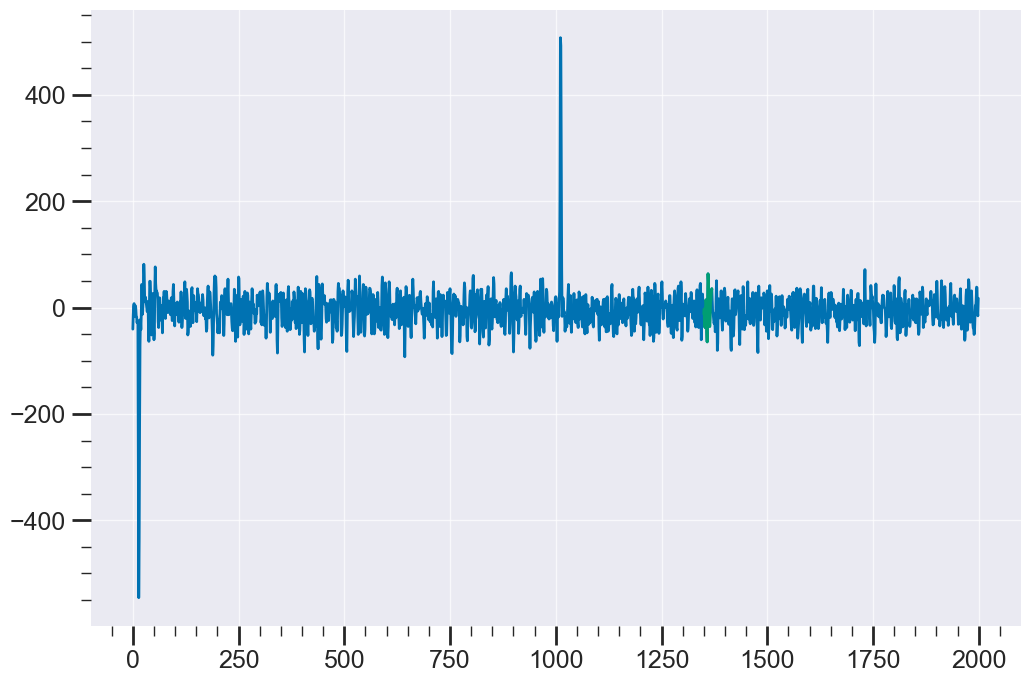

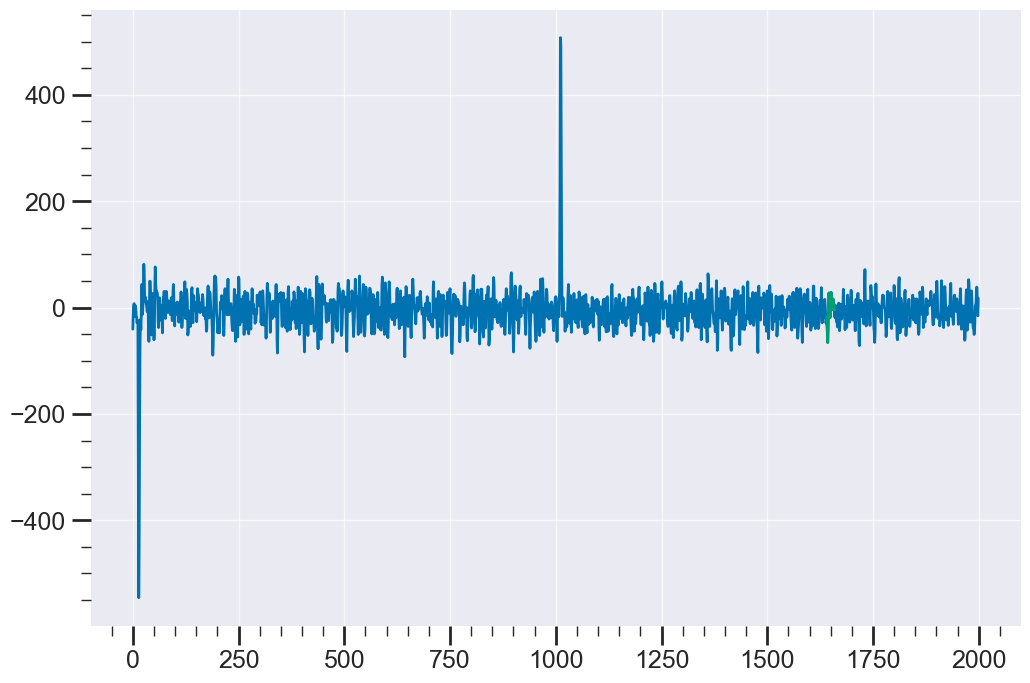

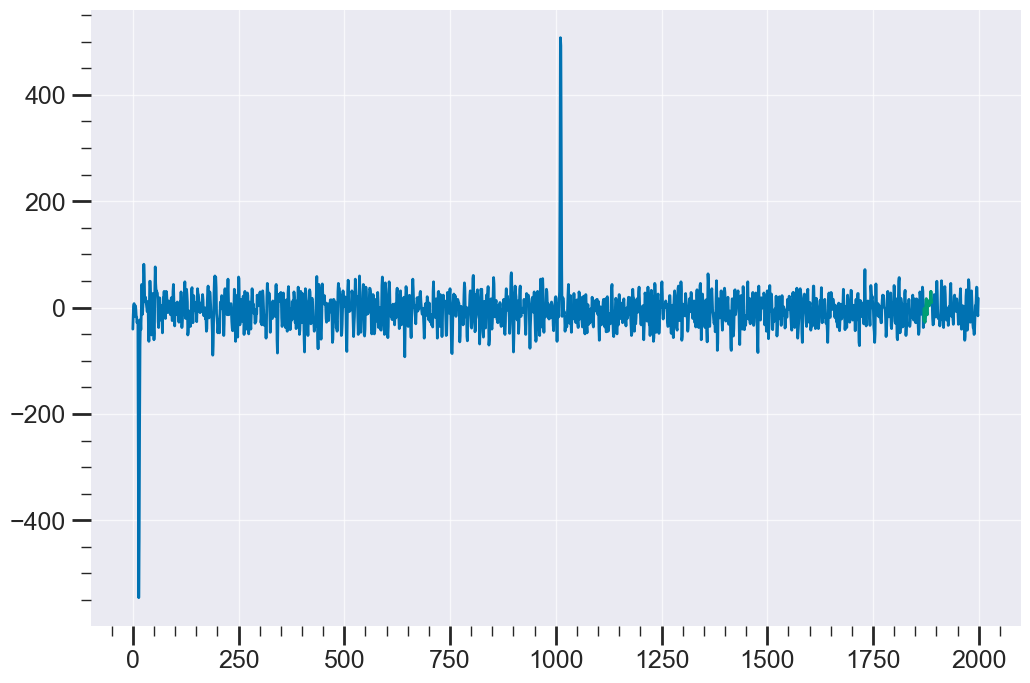

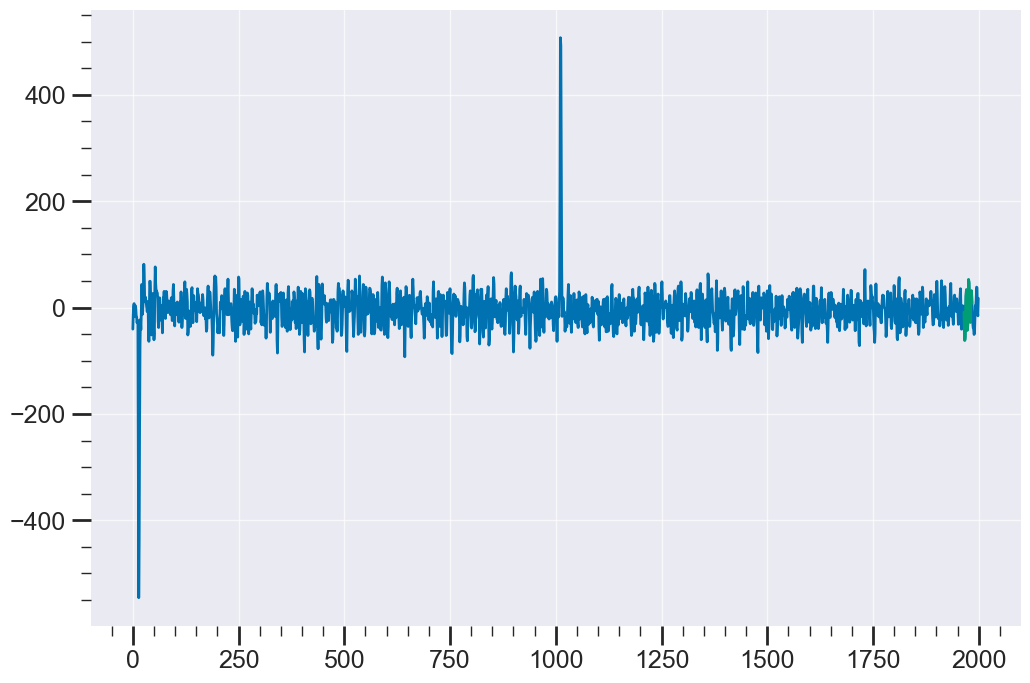

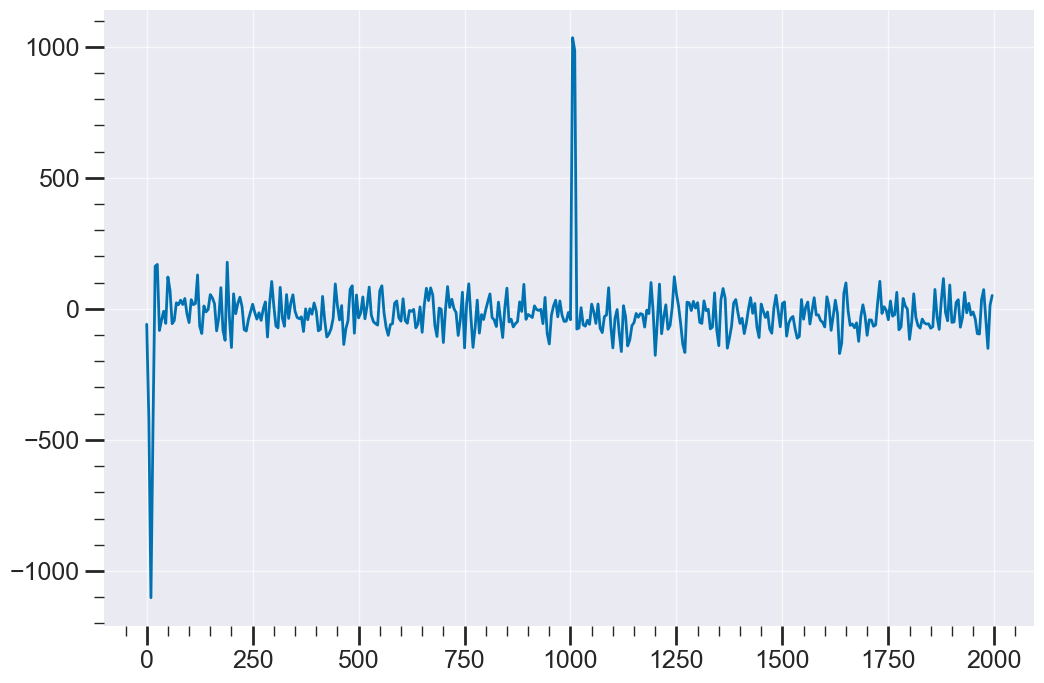

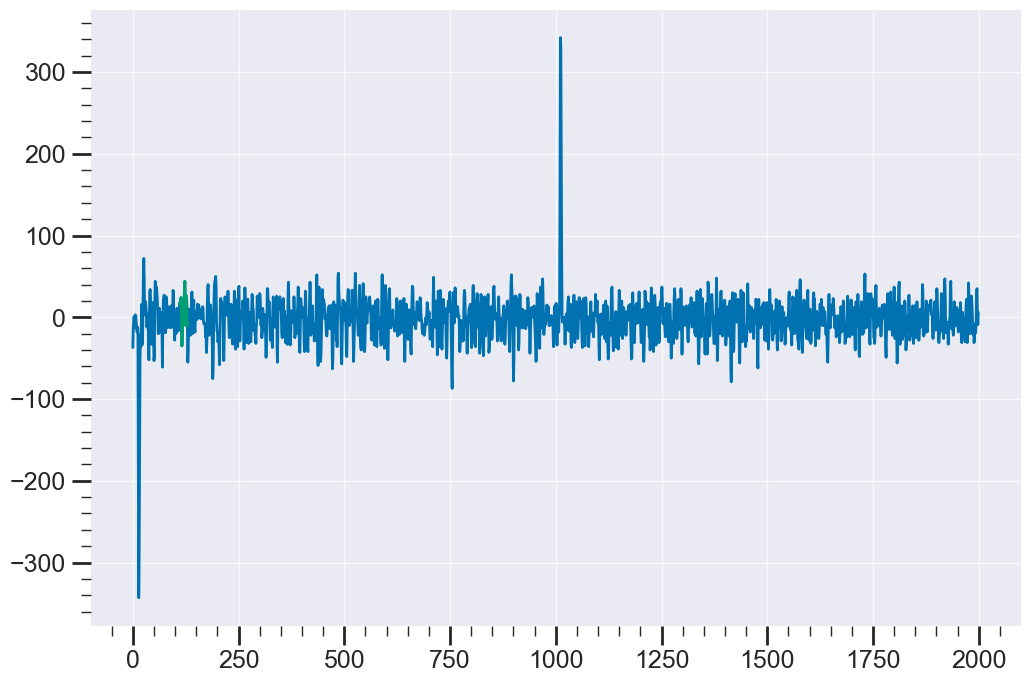

KeyboardInterrupt: 

In [104]:
dr.process_pulses()
#print(np.where(np.array(dr.red_df["n_pulses"]) > 0)[0])
#print(len(dr.red_df["ch0 baseline"]))

../../../data/MockTileRun1/Gamma_Data_Post_Surgery_7_15_24/prereduced/Gamma_Data_Post_Surgery_5kV_7_15_24_initcryo_4_6g_24pt_1000us_file15.p
loading the waveform dataframe from  ../../../data/MockTileRun1/Gamma_Data_Post_Surgery_7_15_24/prereduced/Gamma_Data_Post_Surgery_5kV_7_15_24_initcryo_4_6g_24pt_1000us_file15.p
Done loading


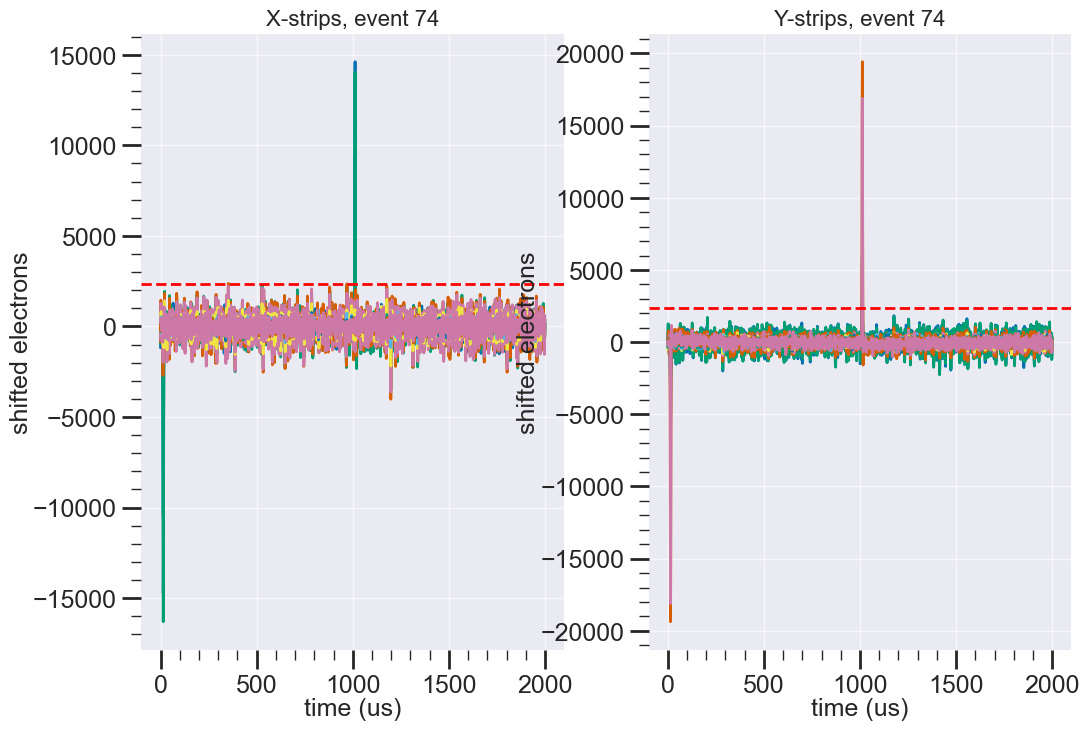

../../../data/MockTileRun1/Gamma_Data_Post_Surgery_7_15_24/prereduced/Gamma_Data_Post_Surgery_5kV_7_15_24_initcryo_4_6g_24pt_1000us_file15.p
loading the waveform dataframe from  ../../../data/MockTileRun1/Gamma_Data_Post_Surgery_7_15_24/prereduced/Gamma_Data_Post_Surgery_5kV_7_15_24_initcryo_4_6g_24pt_1000us_file15.p
Done loading


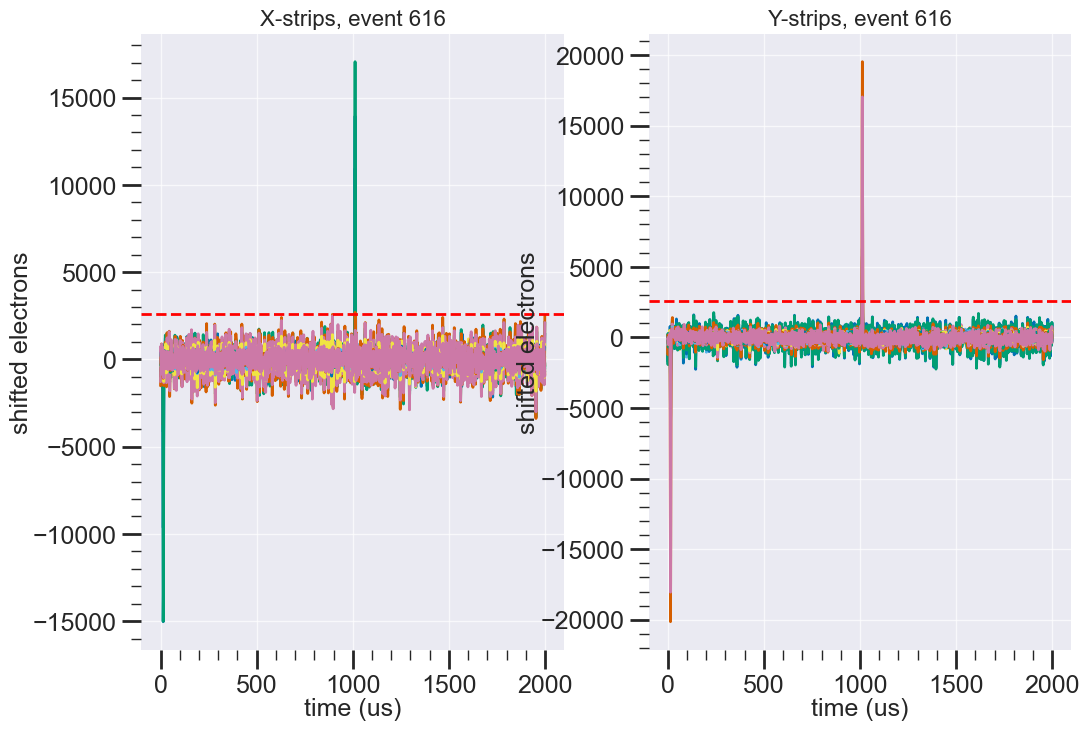

In [29]:
#plot random event waveforms and their associated reduced quantities
df = pd.DataFrame.from_dict(dr.red_df)

n = 2
#choose N random events
evs = df.sample(n)
for i, ev in evs.iterrows():
	#get the file associated with the waveform
	file = ev["filename"]
	print(file)
	idx = ev["evidx"]
	#load the file
	ca = CryoAsicAnalysis.CryoAsicAnalysis(file, config_path)
	ca.baseline_subtract()
	fig, ax = plt.subplots(ncols=2)
	ca.plot_strips_waveforms_separated(idx, fig=fig, ax=ax, sep=0, show=False)

	#plot max of pulses across all strips
	max_enc = 0 
	for ch in ca.df["Channels"].loc[idx]:
		chmax = ev["ch{:d} max".format(ch)]
		if(chmax > max_enc):
			max_enc = chmax
	
	ax[0].axhline(max_enc, color='r', linestyle='--')
	ax[1].axhline(max_enc, color='r', linestyle='--')

	plt.show()

In [51]:
x = np.array([1,2,3,4])
print(np.where(x == 2)[0][0])

1


In [84]:
x = [1]
print(Util.simple_1d_clustering(x, 1))

[[1]]
